In [7]:
import pandas as pd
import numpy as np
from linearmodels.panel import PanelOLS

# =========================
# 1. Load data
# =========================
file_path = "/Volumes/ORICO/Dissertation/output/panel_PCA_AI_PreAI_ready_v3.xlsx"
df = pd.read_excel(file_path)

# =========================
# 2. Sort panel
# =========================
df = df.sort_values(["gvkey", "year"]).copy()

# =========================
# 3. Create lagged AI / Pre-AI
# =========================
df["AI_Focus_L1"] = df.groupby("gvkey")["AI_Focus_per_million_words"].shift(1)
df["PreAI_Focus_L1"] = df.groupby("gvkey")["PreAI_Focus_per_million_words"].shift(1)

# optional: log versions
df["AI_Focus_log"] = np.log1p(df["AI_Focus_per_million_words"])
df["PreAI_Focus_log"] = np.log1p(df["PreAI_Focus_per_million_words"])
df["AI_Focus_log_L1"] = df.groupby("gvkey")["AI_Focus_log"].shift(1)
df["PreAI_Focus_log_L1"] = df.groupby("gvkey")["PreAI_Focus_log"].shift(1)

# =========================
# 4. Create lagged PCA bundles
# =========================
df["operational_pc1_L1"] = df.groupby("gvkey")["operational_pc1"].shift(1)
df["physical_pc1_L1"] = df.groupby("gvkey")["physical_pc1"].shift(1)

# =========================
# 5. Create transformed DVs if needed
# =========================
if "gop" in df.columns:
    df["asinh_gop"] = np.arcsinh(df["gop"])

if "ni_dv" in df.columns:
    df["asinh_ni_dv"] = np.arcsinh(df["ni_dv"])

# =========================
# 6. Create lagged controls if missing
# =========================
# market_share L1
if "market_share" in df.columns and "market_share_L1" not in df.columns:
    df["market_share_L1"] = df.groupby("gvkey")["market_share"].shift(1)

# =========================
# 7. Choose controls
# =========================
controls_simple = [
    "operational_pc1_L1",
    "physical_pc1_L1",
    "size_ln_at_L1",
    "lev_L1"
]

controls_full = [
    "operational_pc1_L1",
    "physical_pc1_L1",
    "size_ln_at_L1",
    "lev_L1",
    "liquidity_L1",
    "asset_turnover_L1",
    "z_score_L1",
    "distress_dummy_L1",
    "firm_hhi_L1"
]

if "market_share_L1" in df.columns:
    controls_full.append("market_share_L1")

# =========================
# 8. Choose IV version
# =========================
# option A: raw AI measures
main_iv_raw = ["AI_Focus_L1", "PreAI_Focus_L1"]

# option B: log AI measures
main_iv_log = ["AI_Focus_log_L1", "PreAI_Focus_log_L1"]

# 여기서는 raw 버전부터 사용
main_iv = main_iv_raw

# =========================
# 9. Choose DVs
# =========================
dv_list = [
    "asinh_gop",
    "gop_w",
    "ni_dv",
    "asinh_ni_dv",
    "tobinq",
    "tobinq_w",
    "roa",
    "roa_w",
    "ros",
    "ros_w",
    "operating_margin",
    "operating_margin_w",
    "sales_growth",
    "sales_growth_w"
]

dv_list = [dv for dv in dv_list if dv in df.columns]

# =========================
# 10. Clean infinities globally
# =========================
df = df.replace([np.inf, -np.inf], np.nan)

# =========================
# 11. Function to run one model
# =========================
def run_panel_model(data, dv, iv_list, control_list):
    temp = data.copy()

    # create DV lag
    dv_lag = f"{dv}_L1"
    temp[dv_lag] = temp.groupby("gvkey")[dv].shift(1)

    needed_cols = ["gvkey", "year", dv, dv_lag] + iv_list + control_list
    temp = temp[needed_cols].copy()

    # replace inf again just in case
    temp = temp.replace([np.inf, -np.inf], np.nan)

    # drop missing
    temp = temp.dropna()

    if len(temp) < 100:
        return None, None

    temp = temp.set_index(["gvkey", "year"])

    y = temp[dv]
    X = temp[[dv_lag] + iv_list + control_list]

    model = PanelOLS(
        y,
        X,
        entity_effects=True,
        time_effects=True,
        drop_absorbed=True
    )

    res = model.fit(cov_type="clustered", cluster_entity=True)
    return res, len(temp)

# =========================
# 12. Run all models
# =========================
results_simple = {}
results_full = {}

summary_rows = []

for dv in dv_list:
    # simple controls
    res_s, n_s = run_panel_model(df, dv, main_iv, controls_simple)
    if res_s is not None:
        results_simple[dv] = res_s
        summary_rows.append({
            "Model": "Simple",
            "DV": dv,
            "N": res_s.nobs,
            "R2_within": res_s.rsquared_within,
            "R2_overall": res_s.rsquared_overall,
            "DV_L1_coef": res_s.params.get(f"{dv}_L1", np.nan),
            "DV_L1_p": res_s.pvalues.get(f"{dv}_L1", np.nan),
            "AI_coef": res_s.params.get(main_iv[0], np.nan),
            "AI_p": res_s.pvalues.get(main_iv[0], np.nan),
            "PreAI_coef": res_s.params.get(main_iv[1], np.nan),
            "PreAI_p": res_s.pvalues.get(main_iv[1], np.nan),
        })

    # full controls
    res_f, n_f = run_panel_model(df, dv, main_iv, controls_full)
    if res_f is not None:
        results_full[dv] = res_f
        summary_rows.append({
            "Model": "Full",
            "DV": dv,
            "N": res_f.nobs,
            "R2_within": res_f.rsquared_within,
            "R2_overall": res_f.rsquared_overall,
            "DV_L1_coef": res_f.params.get(f"{dv}_L1", np.nan),
            "DV_L1_p": res_f.pvalues.get(f"{dv}_L1", np.nan),
            "AI_coef": res_f.params.get(main_iv[0], np.nan),
            "AI_p": res_f.pvalues.get(main_iv[0], np.nan),
            "PreAI_coef": res_f.params.get(main_iv[1], np.nan),
            "PreAI_p": res_f.pvalues.get(main_iv[1], np.nan),
        })

# =========================
# 13. Print full summaries
# =========================
print("\n" + "=" * 120)
print("SIMPLE MODELS")
print("=" * 120)
for dv, res in results_simple.items():
    print("\n" + "=" * 100)
    print(f"DV: {dv}")
    print("=" * 100)
    print(res.summary)

print("\n" + "=" * 120)
print("FULL MODELS")
print("=" * 120)
for dv, res in results_full.items():
    print("\n" + "=" * 100)
    print(f"DV: {dv}")
    print("=" * 100)
    print(res.summary)

# =========================
# 14. Save summary table
# =========================
summary_df = pd.DataFrame(summary_rows)
summary_df = summary_df.sort_values(["DV", "Model"]).reset_index(drop=True)

print("\nCompact summary:")
print(summary_df)

summary_df.to_excel("dynamic_panel_summary.xlsx", index=False)

# =========================
# 15. Save key coefficients separately
# =========================
coef_rows = []

for model_name, results_dict in [("Simple", results_simple), ("Full", results_full)]:
    for dv, res in results_dict.items():
        vars_to_keep = [f"{dv}_L1"] + main_iv
        for var in vars_to_keep:
            if var in res.params.index:
                ci = res.conf_int().loc[var]
                coef_rows.append({
                    "Model": model_name,
                    "DV": dv,
                    "Variable": var,
                    "Coef": res.params[var],
                    "StdErr": res.std_errors[var],
                    "t": res.tstats[var],
                    "p": res.pvalues[var],
                    "CI_low": ci[0],
                    "CI_high": ci[1],
                    "N": res.nobs,
                    "R2_within": res.rsquared_within
                })

coef_df = pd.DataFrame(coef_rows)
coef_df.to_excel("dynamic_panel_key_coefficients.xlsx", index=False)

print("\nSaved files:")
print("- dynamic_panel_summary.xlsx")
print("- dynamic_panel_key_coefficients.xlsx")


SIMPLE MODELS

DV: asinh_gop
                          PanelOLS Estimation Summary                           
Dep. Variable:              asinh_gop   R-squared:                        0.1065
Estimator:                   PanelOLS   R-squared (Between):              0.8658
No. Observations:                1402   R-squared (Within):               0.1029
Date:                Mon, Apr 20 2026   R-squared (Overall):              0.8558
Time:                        21:16:53   Log-likelihood                   -2336.7
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      21.363
Entities:                         125   P-value                           0.0000
Avg Obs:                       11.216   Distribution:                  F(7,1255)
Min Obs:                       1.0000                                           
Max Obs:                       49.000   F-statistic (robust):             9.732

/var/folders/9q/rg7dh5cj2mx7xmtkv28d6jm80000gn/T/ipykernel_2664/1860631992.py:248: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  "CI_low": ci[0],
/var/folders/9q/rg7dh5cj2mx7xmtkv28d6jm80000gn/T/ipykernel_2664/1860631992.py:249: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  "CI_high": ci[1],


In [9]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from linearmodels.panel import PanelOLS

########################################
# 1. Load data
########################################

file_path = "/Volumes/ORICO/Dissertation/output/panel_PCA_AI_PreAI_ready_v3.xlsx"
df = pd.read_excel(file_path)

# 정렬 먼저
df = df.sort_values(["gvkey", "year"]).copy()

########################################
# 2. Create transformed DVs
########################################

if "gop" in df.columns:
    df["asinh_gop"] = np.arcsinh(df["gop"])

if "ni_dv" in df.columns:
    df["asinh_ni_dv"] = np.arcsinh(df["ni_dv"])

########################################
# 3. Create L1 variables
########################################

# AI / PreAI
if "AI_Focus_per_million_words" in df.columns:
    df["AI_Focus_L1"] = df.groupby("gvkey")["AI_Focus_per_million_words"].shift(1)

if "PreAI_Focus_per_million_words" in df.columns:
    df["PreAI_Focus_L1"] = df.groupby("gvkey")["PreAI_Focus_per_million_words"].shift(1)

# PCA bundles
if "operational_pc1" in df.columns:
    df["operational_pc1_L1"] = df.groupby("gvkey")["operational_pc1"].shift(1)

if "physical_pc1" in df.columns:
    df["physical_pc1_L1"] = df.groupby("gvkey")["physical_pc1"].shift(1)

# market share
if "market_share" in df.columns:
    df["market_share_L1"] = df.groupby("gvkey")["market_share"].shift(1)

########################################
# 4. DV list
########################################

dv_list = [
    "asinh_gop",
    "gop_w",
    "ni_dv",
    "asinh_ni_dv",
    "operating_margin",
    "operating_margin_w",
    "roa",
    "roa_w",
    "ros",
    "ros_w",
    "sales_growth",
    "sales_growth_w",
    "tobinq",
    "tobinq_w"
]

# 실제 존재하는 DV만 사용
dv_list = [dv for dv in dv_list if dv in df.columns]

########################################
# 5. Create DV L1s
########################################

for dv in dv_list:
    df[f"{dv}_L1"] = df.groupby("gvkey")[dv].shift(1)

########################################
# 6. Replace inf values
########################################

df = df.replace([np.inf, -np.inf], np.nan)

########################################
# 7. Set panel index
########################################

df = df.set_index(["gvkey", "year"])

########################################
# 8. Controls
########################################

controls_simple = [
    "AI_Focus_L1",
    "PreAI_Focus_L1",
    "operational_pc1_L1",
    "physical_pc1_L1",
    "size_ln_at_L1",
    "lev_L1"
]

controls_full = [
    "AI_Focus_L1",
    "PreAI_Focus_L1",
    "operational_pc1_L1",
    "physical_pc1_L1",
    "size_ln_at_L1",
    "lev_L1",
    "liquidity_L1",
    "asset_turnover_L1",
    "z_score_L1",
    "distress_dummy_L1",
    "firm_hhi_L1",
    "market_share_L1"
]

# 실제 존재하는 컬럼만 남김
controls_simple = [c for c in controls_simple if c in df.columns]
controls_full = [c for c in controls_full if c in df.columns]

########################################
# 9. Regression function
########################################

def run_panel_regression(data, dv, controls, model_name="Model"):
    dv_lag = f"{dv}_L1"

    needed_cols = [dv, dv_lag] + controls
    needed_cols = [c for c in needed_cols if c in data.columns]

    model_df = data[needed_cols].dropna().copy()

    if len(model_df) < 100:
        print(f"Skipping {dv} in {model_name}: too few observations ({len(model_df)})")
        return None

    y = model_df[dv]
    X = model_df[[dv_lag] + controls]

    # constant는 FE 모델에서 사실 필수는 아니지만 유지해도 무방
    # 흡수되므로 큰 문제는 없음. 원하면 빼도 됨.
    X = sm.add_constant(X)

    model = PanelOLS(
        dependent=y,
        exog=X,
        entity_effects=True,
        time_effects=True,
        drop_absorbed=True
    )

    result = model.fit(
        cov_type="clustered",
        cluster_entity=True
    )

    print("\n" + "=" * 100)
    print(f"{model_name} | DV: {dv}")
    print("=" * 100)
    print(result.summary)

    return result

########################################
# 10. Run all models
########################################

results_summary = []

for dv in dv_list:

    # Simple
    res_s = run_panel_regression(df, dv, controls_simple, model_name="Simple")
    if res_s is not None:
        results_summary.append({
            "Model": "Simple",
            "DV": dv,
            "N": res_s.nobs,
            "R2_within": res_s.rsquared_within,
            "R2_overall": res_s.rsquared_overall,
            "DV_L1_coef": res_s.params.get(f"{dv}_L1", np.nan),
            "DV_L1_p": res_s.pvalues.get(f"{dv}_L1", np.nan),
            "AI_coef": res_s.params.get("AI_Focus_L1", np.nan),
            "AI_p": res_s.pvalues.get("AI_Focus_L1", np.nan),
            "PreAI_coef": res_s.params.get("PreAI_Focus_L1", np.nan),
            "PreAI_p": res_s.pvalues.get("PreAI_Focus_L1", np.nan),
        })

    # Full
    res_f = run_panel_regression(df, dv, controls_full, model_name="Full")
    if res_f is not None:
        results_summary.append({
            "Model": "Full",
            "DV": dv,
            "N": res_f.nobs,
            "R2_within": res_f.rsquared_within,
            "R2_overall": res_f.rsquared_overall,
            "DV_L1_coef": res_f.params.get(f"{dv}_L1", np.nan),
            "DV_L1_p": res_f.pvalues.get(f"{dv}_L1", np.nan),
            "AI_coef": res_f.params.get("AI_Focus_L1", np.nan),
            "AI_p": res_f.pvalues.get("AI_Focus_L1", np.nan),
            "PreAI_coef": res_f.params.get("PreAI_Focus_L1", np.nan),
            "PreAI_p": res_f.pvalues.get("PreAI_Focus_L1", np.nan),
        })

########################################
# 11. Summary
########################################

summary_df = pd.DataFrame(results_summary)
print("\nCompact summary:")
print(summary_df)

summary_df.to_excel("dynamic_panel_full_results.xlsx", index=False)
print("\nSaved: dynamic_panel_full_results.xlsx")


Simple | DV: asinh_gop
                          PanelOLS Estimation Summary                           
Dep. Variable:              asinh_gop   R-squared:                        0.1065
Estimator:                   PanelOLS   R-squared (Between):              0.6396
No. Observations:                1402   R-squared (Within):               0.1029
Date:                Mon, Apr 20 2026   R-squared (Overall):              0.5372
Time:                        21:22:56   Log-likelihood                   -2336.7
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      21.363
Entities:                         125   P-value                           0.0000
Avg Obs:                       11.216   Distribution:                  F(7,1255)
Min Obs:                       1.0000                                           
Max Obs:                       49.000   F-statistic (robust):             9.7322
    

In [10]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from linearmodels.panel import PanelOLS

########################################
# 1. Load data
########################################

file_path = "/Volumes/ORICO/Dissertation/output/panel_PCA_AI_PreAI_ready_v3.xlsx"
df = pd.read_excel(file_path)

########################################
# 2. Sort panel
########################################

df = df.sort_values(["gvkey", "year"]).copy()

########################################
# 3. Create transformed DVs if needed
########################################

if "gop" in df.columns and "asinh_gop" not in df.columns:
    df["asinh_gop"] = np.arcsinh(df["gop"])

if "ni_dv" in df.columns and "asinh_ni_dv" not in df.columns:
    df["asinh_ni_dv"] = np.arcsinh(df["ni_dv"])

########################################
# 4. Create lagged AI / PreAI if needed
########################################

if "AI_Focus_L1" not in df.columns:
    df["AI_Focus_L1"] = df.groupby("gvkey")["AI_Focus_per_million_words"].shift(1)

if "PreAI_Focus_L1" not in df.columns:
    df["PreAI_Focus_L1"] = df.groupby("gvkey")["PreAI_Focus_per_million_words"].shift(1)

########################################
# 5. Create lagged PCA bundles if needed
########################################

if "operational_pc1_L1" not in df.columns:
    df["operational_pc1_L1"] = df.groupby("gvkey")["operational_pc1"].shift(1)

if "physical_pc1_L1" not in df.columns:
    df["physical_pc1_L1"] = df.groupby("gvkey")["physical_pc1"].shift(1)

if "market_share_L1" not in df.columns and "market_share" in df.columns:
    df["market_share_L1"] = df.groupby("gvkey")["market_share"].shift(1)

########################################
# 6. Interaction terms
########################################

df["AI_operational_int"] = df["AI_Focus_L1"] * df["operational_pc1_L1"]
df["AI_physical_int"] = df["AI_Focus_L1"] * df["physical_pc1_L1"]
df["AI_intan_int"] = df["AI_Focus_L1"] * df["intan_at_L1"]

########################################
# 7. DV list
########################################

dv_list = [
    "asinh_gop",
    "gop_w",
    "ni_dv",
    "asinh_ni_dv",
    "operating_margin",
    "operating_margin_w",
    "roa",
    "roa_w",
    "ros",
    "ros_w",
    "sales_growth",
    "sales_growth_w",
    "tobinq",
    "tobinq_w"
]

dv_list = [dv for dv in dv_list if dv in df.columns]

########################################
# 8. Create DV lags
########################################

for dv in dv_list:
    lag_name = f"{dv}_L1"
    if lag_name not in df.columns:
        df[lag_name] = df.groupby("gvkey")[dv].shift(1)

########################################
# 9. Clean inf
########################################

df = df.replace([np.inf, -np.inf], np.nan)

########################################
# 10. Set panel index
########################################

df = df.set_index(["gvkey", "year"])

########################################
# 11. Interaction model specs
########################################

controls_simple_int = [
    "AI_Focus_L1",
    "PreAI_Focus_L1",
    "operational_pc1_L1",
    "physical_pc1_L1",
    "intan_at_L1",
    "AI_operational_int",
    "AI_physical_int",
    "AI_intan_int",
    "size_ln_at_L1",
    "lev_L1"
]

controls_full_int = [
    "AI_Focus_L1",
    "PreAI_Focus_L1",
    "operational_pc1_L1",
    "physical_pc1_L1",
    "intan_at_L1",
    "AI_operational_int",
    "AI_physical_int",
    "AI_intan_int",
    "size_ln_at_L1",
    "lev_L1",
    "liquidity_L1",
    "asset_turnover_L1",
    "z_score_L1",
    "distress_dummy_L1",
    "firm_hhi_L1",
    "market_share_L1"
]

controls_simple_int = [c for c in controls_simple_int if c in df.columns]
controls_full_int = [c for c in controls_full_int if c in df.columns]

########################################
# 12. Regression function
########################################

def run_panel_regression(data, dv, controls, model_name="Model"):
    dv_lag = f"{dv}_L1"

    needed_cols = [dv, dv_lag] + controls
    needed_cols = [c for c in needed_cols if c in data.columns]

    model_df = data[needed_cols].dropna().copy()

    if len(model_df) < 100:
        print(f"Skipping {dv} in {model_name}: too few observations ({len(model_df)})")
        return None

    y = model_df[dv]
    X = model_df[[dv_lag] + controls]
    X = sm.add_constant(X)

    model = PanelOLS(
        dependent=y,
        exog=X,
        entity_effects=True,
        time_effects=True,
        drop_absorbed=True
    )

    result = model.fit(
        cov_type="clustered",
        cluster_entity=True
    )

    print("\n" + "=" * 100)
    print(f"{model_name} | DV: {dv}")
    print("=" * 100)
    print(result.summary)

    return result

########################################
# 13. Run all models
########################################

results_summary = []

for dv in dv_list:

    res_s = run_panel_regression(df, dv, controls_simple_int, model_name="Simple_INT")
    if res_s is not None:
        results_summary.append({
            "Model": "Simple_INT",
            "DV": dv,
            "N": res_s.nobs,
            "R2_within": res_s.rsquared_within,
            "AI_coef": res_s.params.get("AI_Focus_L1", np.nan),
            "AI_p": res_s.pvalues.get("AI_Focus_L1", np.nan),
            "PreAI_coef": res_s.params.get("PreAI_Focus_L1", np.nan),
            "PreAI_p": res_s.pvalues.get("PreAI_Focus_L1", np.nan),
            "AI_oper_coef": res_s.params.get("AI_operational_int", np.nan),
            "AI_oper_p": res_s.pvalues.get("AI_operational_int", np.nan),
            "AI_phys_coef": res_s.params.get("AI_physical_int", np.nan),
            "AI_phys_p": res_s.pvalues.get("AI_physical_int", np.nan),
            "AI_intan_coef": res_s.params.get("AI_intan_int", np.nan),
            "AI_intan_p": res_s.pvalues.get("AI_intan_int", np.nan),
        })

    res_f = run_panel_regression(df, dv, controls_full_int, model_name="Full_INT")
    if res_f is not None:
        results_summary.append({
            "Model": "Full_INT",
            "DV": dv,
            "N": res_f.nobs,
            "R2_within": res_f.rsquared_within,
            "AI_coef": res_f.params.get("AI_Focus_L1", np.nan),
            "AI_p": res_f.pvalues.get("AI_Focus_L1", np.nan),
            "PreAI_coef": res_f.params.get("PreAI_Focus_L1", np.nan),
            "PreAI_p": res_f.pvalues.get("PreAI_Focus_L1", np.nan),
            "AI_oper_coef": res_f.params.get("AI_operational_int", np.nan),
            "AI_oper_p": res_f.pvalues.get("AI_operational_int", np.nan),
            "AI_phys_coef": res_f.params.get("AI_physical_int", np.nan),
            "AI_phys_p": res_f.pvalues.get("AI_physical_int", np.nan),
            "AI_intan_coef": res_f.params.get("AI_intan_int", np.nan),
            "AI_intan_p": res_f.pvalues.get("AI_intan_int", np.nan),
        })

########################################
# 14. Save summary
########################################

summary_df = pd.DataFrame(results_summary)
summary_df = summary_df.sort_values(["DV", "Model"]).reset_index(drop=True)

print("\nCompact summary:")
print(summary_df)

summary_df.to_excel("dynamic_panel_interaction_results.xlsx", index=False)
print("\nSaved: dynamic_panel_interaction_results.xlsx")


Simple_INT | DV: asinh_gop
                          PanelOLS Estimation Summary                           
Dep. Variable:              asinh_gop   R-squared:                        0.1072
Estimator:                   PanelOLS   R-squared (Between):              0.6302
No. Observations:                1378   R-squared (Within):               0.1050
Date:                Mon, Apr 20 2026   R-squared (Overall):              0.5340
Time:                        21:32:11   Log-likelihood                   -2305.7
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      13.409
Entities:                         123   P-value                           0.0000
Avg Obs:                       11.203   Distribution:                 F(11,1229)
Min Obs:                       1.0000                                           
Max Obs:                       49.000   F-statistic (robust):             6.8312


In [11]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from linearmodels.panel import PanelOLS

# =========================================================
# 0. Load
# =========================================================
file_path = "/Volumes/ORICO/Dissertation/output/panel_PCA_AI_PreAI_ready_v3.xlsx"
df = pd.read_excel(file_path)

# panel sort
df = df.sort_values(["gvkey", "year"]).copy()

# =========================================================
# 1. Basic variable preparation
# =========================================================
# transformed DVs if not already present
if "asinh_gop" not in df.columns and "gop" in df.columns:
    df["asinh_gop"] = np.arcsinh(df["gop"])

if "asinh_ni_dv" not in df.columns and "ni_dv" in df.columns:
    df["asinh_ni_dv"] = np.arcsinh(df["ni_dv"])

# AI / PreAI lag 1 if missing
if "AI_Focus_L1" not in df.columns and "AI_Focus_per_million_words" in df.columns:
    df["AI_Focus_L1"] = df.groupby("gvkey")["AI_Focus_per_million_words"].shift(1)

if "PreAI_Focus_L1" not in df.columns and "PreAI_Focus_per_million_words" in df.columns:
    df["PreAI_Focus_L1"] = df.groupby("gvkey")["PreAI_Focus_per_million_words"].shift(1)

# resource lags if missing
if "operational_pc1_L1" not in df.columns and "operational_pc1" in df.columns:
    df["operational_pc1_L1"] = df.groupby("gvkey")["operational_pc1"].shift(1)

if "physical_pc1_L1" not in df.columns and "physical_pc1" in df.columns:
    df["physical_pc1_L1"] = df.groupby("gvkey")["physical_pc1"].shift(1)

if "market_share_L1" not in df.columns and "market_share" in df.columns:
    df["market_share_L1"] = df.groupby("gvkey")["market_share"].shift(1)

# intan_at_L1 already exists in your file, but keep a safeguard
if "intan_at_L1" not in df.columns:
    if "intan_at" in df.columns:
        df["intan_at_L1"] = df.groupby("gvkey")["intan_at"].shift(1)
    elif ("intan" in df.columns) and ("at" in df.columns):
        df["intan_at"] = df["intan"] / df["at"]
        df["intan_at_L1"] = df.groupby("gvkey")["intan_at"].shift(1)
    else:
        raise KeyError("intan_at_L1도 없고 intan/at도 없습니다.")

# =========================================================
# 2. DV list
# =========================================================
dv_list = [
    "asinh_gop",
    "gop_w",
    "ni_dv",
    "asinh_ni_dv",
    "operating_margin",
    "operating_margin_w",
    "roa",
    "roa_w",
    "ros",
    "ros_w",
    "sales_growth",
    "sales_growth_w",
    "tobinq",
    "tobinq_w"
]
dv_list = [dv for dv in dv_list if dv in df.columns]

# DV lag 1 / 2 / 3
for dv in dv_list:
    if f"{dv}_L1" not in df.columns:
        df[f"{dv}_L1"] = df.groupby("gvkey")[dv].shift(1)
    if f"{dv}_L2" not in df.columns:
        df[f"{dv}_L2"] = df.groupby("gvkey")[dv].shift(2)
    if f"{dv}_L3" not in df.columns:
        df[f"{dv}_L3"] = df.groupby("gvkey")[dv].shift(3)

# =========================================================
# 3. Higher-order lags for AI and resources
# =========================================================
lag_sources = {
    "AI_Focus_per_million_words": "AI_Focus",
    "PreAI_Focus_per_million_words": "PreAI_Focus",
    "operational_pc1": "operational_pc1",
    "physical_pc1": "physical_pc1",
    "intan_at": "intan_at"
}

# if intan_at raw not present but intan_at_L1 exists, recreate raw when possible
if "intan_at" not in df.columns and ("intan" in df.columns) and ("at" in df.columns):
    df["intan_at"] = df["intan"] / df["at"]

for raw_col, base_name in lag_sources.items():
    if raw_col in df.columns:
        for L in [1, 2, 3]:
            lag_col = f"{base_name}_L{L}"
            if lag_col not in df.columns:
                df[lag_col] = df.groupby("gvkey")[raw_col].shift(L)

# =========================================================
# 4. Standardization helper
# =========================================================
def zscore_series(s: pd.Series) -> pd.Series:
    std = s.std(skipna=True)
    if pd.isna(std) or std == 0:
        return pd.Series(np.nan, index=s.index)
    return (s - s.mean(skipna=True)) / std

z_vars = [
    "AI_Focus_L1",
    "operational_pc1_L1",
    "physical_pc1_L1",
    "intan_at_L1"
]

for v in z_vars:
    if v in df.columns:
        zname = f"z_{v}"
        if zname not in df.columns:
            df[zname] = zscore_series(df[v])

# standardized interactions
df["z_AI_operational_int"] = df["z_AI_Focus_L1"] * df["z_operational_pc1_L1"]
df["z_AI_physical_int"] = df["z_AI_Focus_L1"] * df["z_physical_pc1_L1"]
df["z_AI_intan_int"] = df["z_AI_Focus_L1"] * df["z_intan_at_L1"]

# raw interactions
df["AI_operational_int"] = df["AI_Focus_L1"] * df["operational_pc1_L1"]
df["AI_physical_int"] = df["AI_Focus_L1"] * df["physical_pc1_L1"]
df["AI_intan_int"] = df["AI_Focus_L1"] * df["intan_at_L1"]

# optional: L2/L3 interactions for ARDL-style model
if all(c in df.columns for c in ["AI_Focus_L2", "operational_pc1_L2"]):
    df["AI_operational_int_L2"] = df["AI_Focus_L2"] * df["operational_pc1_L2"]
if all(c in df.columns for c in ["AI_Focus_L2", "physical_pc1_L2"]):
    df["AI_physical_int_L2"] = df["AI_Focus_L2"] * df["physical_pc1_L2"]
if all(c in df.columns for c in ["AI_Focus_L2", "intan_at_L2"]):
    df["AI_intan_int_L2"] = df["AI_Focus_L2"] * df["intan_at_L2"]

if all(c in df.columns for c in ["AI_Focus_L3", "operational_pc1_L3"]):
    df["AI_operational_int_L3"] = df["AI_Focus_L3"] * df["operational_pc1_L3"]
if all(c in df.columns for c in ["AI_Focus_L3", "physical_pc1_L3"]):
    df["AI_physical_int_L3"] = df["AI_Focus_L3"] * df["physical_pc1_L3"]
if all(c in df.columns for c in ["AI_Focus_L3", "intan_at_L3"]):
    df["AI_intan_int_L3"] = df["AI_Focus_L3"] * df["intan_at_L3"]

# =========================================================
# 5. Clean
# =========================================================
df = df.replace([np.inf, -np.inf], np.nan)
df = df.set_index(["gvkey", "year"])

# =========================================================
# 6. Control sets
# =========================================================
basic_controls = [
    "size_ln_at_L1",
    "lev_L1"
]

full_controls = [
    "size_ln_at_L1",
    "lev_L1",
    "liquidity_L1",
    "asset_turnover_L1",
    "z_score_L1",
    "distress_dummy_L1",
    "firm_hhi_L1",
    "market_share_L1"
]

basic_controls = [c for c in basic_controls if c in df.columns]
full_controls = [c for c in full_controls if c in df.columns]

# =========================================================
# 7. Model specs
# =========================================================
model_specs = {
    # A. standardized interaction model
    "Z_INT_BASIC": [
        "z_AI_Focus_L1",
        "PreAI_Focus_L1",
        "z_operational_pc1_L1",
        "z_physical_pc1_L1",
        "z_intan_at_L1",
        "z_AI_operational_int",
        "z_AI_physical_int",
        "z_AI_intan_int",
    ] + basic_controls,

    "Z_INT_FULL": [
        "z_AI_Focus_L1",
        "PreAI_Focus_L1",
        "z_operational_pc1_L1",
        "z_physical_pc1_L1",
        "z_intan_at_L1",
        "z_AI_operational_int",
        "z_AI_physical_int",
        "z_AI_intan_int",
    ] + full_controls,

    # B. lag 2 model
    "LAG2_FULL": [
        "AI_Focus_L1", "AI_Focus_L2",
        "PreAI_Focus_L1",
        "operational_pc1_L1", "operational_pc1_L2",
        "physical_pc1_L1", "physical_pc1_L2",
        "intan_at_L1", "intan_at_L2",
        "AI_operational_int",
        "AI_physical_int",
        "AI_intan_int",
    ] + full_controls,

    # C. lag 3 / ARDL-style
    "ARDL_FULL": [
        "AI_Focus_L1", "AI_Focus_L2", "AI_Focus_L3",
        "PreAI_Focus_L1",
        "operational_pc1_L1", "operational_pc1_L2", "operational_pc1_L3",
        "physical_pc1_L1", "physical_pc1_L2", "physical_pc1_L3",
        "intan_at_L1", "intan_at_L2", "intan_at_L3",
        "AI_operational_int",
        "AI_physical_int",
        "AI_intan_int",
    ] + full_controls
}

# keep only existing columns
for k, cols in model_specs.items():
    model_specs[k] = [c for c in cols if c in df.columns]

# =========================================================
# 8. Regression function
# =========================================================
def run_panel_regression(data: pd.DataFrame, dv: str, regressors: list, spec_name: str):
    dv_lag = f"{dv}_L1"
    needed_cols = [dv, dv_lag] + regressors
    needed_cols = [c for c in needed_cols if c in data.columns]

    model_df = data[needed_cols].dropna().copy()
    if len(model_df) < 100:
        print(f"Skipping {spec_name} | {dv}: too few observations ({len(model_df)})")
        return None

    y = model_df[dv]
    X = model_df[[dv_lag] + regressors]
    X = sm.add_constant(X)

    model = PanelOLS(
        dependent=y,
        exog=X,
        entity_effects=True,
        time_effects=True,
        drop_absorbed=True
    )

    res = model.fit(cov_type="clustered", cluster_entity=True)

    print("\n" + "=" * 110)
    print(f"{spec_name} | DV: {dv}")
    print("=" * 110)
    print(res.summary)

    return res

# =========================================================
# 9. Run all models
# =========================================================
results_summary = []
results_store = {}

for spec_name, regressors in model_specs.items():
    for dv in dv_list:
        res = run_panel_regression(df, dv, regressors, spec_name)
        if res is None:
            continue

        results_store[(spec_name, dv)] = res

        row = {
            "Spec": spec_name,
            "DV": dv,
            "N": res.nobs,
            "R2_within": res.rsquared_within,
            "R2_overall": res.rsquared_overall,
            "DV_L1_coef": res.params.get(f"{dv}_L1", np.nan),
            "DV_L1_p": res.pvalues.get(f"{dv}_L1", np.nan),
        }

        # main terms if present
        for var in [
            "AI_Focus_L1", "AI_Focus_L2", "AI_Focus_L3",
            "z_AI_Focus_L1",
            "PreAI_Focus_L1",
            "AI_operational_int", "AI_physical_int", "AI_intan_int",
            "z_AI_operational_int", "z_AI_physical_int", "z_AI_intan_int"
        ]:
            row[f"{var}_coef"] = res.params.get(var, np.nan)
            row[f"{var}_p"] = res.pvalues.get(var, np.nan)

        results_summary.append(row)

# =========================================================
# 10. Save summary tables
# =========================================================
summary_df = pd.DataFrame(results_summary)
summary_df = summary_df.sort_values(["DV", "Spec"]).reset_index(drop=True)

print("\nCompact summary:")
print(summary_df)

summary_df.to_excel("panel_dynamic_interaction_lag_ardl_summary.xlsx", index=False)

# key coefficients only
key_rows = []
for (spec_name, dv), res in results_store.items():
    for var in res.params.index:
        if (
            "AI_Focus" in var
            or "PreAI_Focus" in var
            or "AI_operational_int" in var
            or "AI_physical_int" in var
            or "AI_intan_int" in var
            or "z_AI_" in var
            or var == f"{dv}_L1"
        ):
            ci = res.conf_int().loc[var]
            key_rows.append({
                "Spec": spec_name,
                "DV": dv,
                "Variable": var,
                "Coef": res.params[var],
                "StdErr": res.std_errors[var],
                "t": res.tstats[var],
                "p": res.pvalues[var],
                "CI_low": ci.iloc[0],
                "CI_high": ci.iloc[1],
                "N": res.nobs,
                "R2_within": res.rsquared_within
            })

key_df = pd.DataFrame(key_rows)
key_df.to_excel("panel_dynamic_key_coefficients.xlsx", index=False)

print("\nSaved files:")
print("- panel_dynamic_interaction_lag_ardl_summary.xlsx")
print("- panel_dynamic_key_coefficients.xlsx")


Z_INT_BASIC | DV: asinh_gop
                          PanelOLS Estimation Summary                           
Dep. Variable:              asinh_gop   R-squared:                        0.1072
Estimator:                   PanelOLS   R-squared (Between):              0.6302
No. Observations:                1378   R-squared (Within):               0.1050
Date:                Mon, Apr 20 2026   R-squared (Overall):              0.5340
Time:                        21:42:47   Log-likelihood                   -2305.7
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      13.409
Entities:                         123   P-value                           0.0000
Avg Obs:                       11.203   Distribution:                 F(11,1229)
Min Obs:                       1.0000                                           
Max Obs:                       49.000   F-statistic (robust):             6.8312

In [12]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from linearmodels.panel import PanelOLS

# =========================================================
# 0. Load
# =========================================================
file_path = "/Volumes/ORICO/Dissertation/output/panel_PCA_AI_PreAI_ready_v3.xlsx"
df = pd.read_excel(file_path)

df = df.sort_values(["gvkey", "year"]).copy()

# =========================================================
# 1. Create core DVs
# =========================================================
if "asinh_gop" not in df.columns and "gop" in df.columns:
    df["asinh_gop"] = np.arcsinh(df["gop"])

if "asinh_ni_dv" not in df.columns and "ni_dv" in df.columns:
    df["asinh_ni_dv"] = np.arcsinh(df["ni_dv"])

# dissertation main DVs: 3개만 사용
dv_list = [
    "asinh_gop",   # accounting performance
    "asinh_ni_dv", # profitability / earnings
    "tobinq_w"     # market valuation
]
dv_list = [dv for dv in dv_list if dv in df.columns]

# =========================================================
# 2. Create lags
# =========================================================
# AI
if "AI_Focus_L1" not in df.columns:
    df["AI_Focus_L1"] = df.groupby("gvkey")["AI_Focus_per_million_words"].shift(1)
if "AI_Focus_L2" not in df.columns:
    df["AI_Focus_L2"] = df.groupby("gvkey")["AI_Focus_per_million_words"].shift(2)
if "AI_Focus_L3" not in df.columns:
    df["AI_Focus_L3"] = df.groupby("gvkey")["AI_Focus_per_million_words"].shift(3)

# Pre-AI
if "PreAI_Focus_L1" not in df.columns:
    df["PreAI_Focus_L1"] = df.groupby("gvkey")["PreAI_Focus_per_million_words"].shift(1)

# Resource bundles
if "operational_pc1_L1" not in df.columns:
    df["operational_pc1_L1"] = df.groupby("gvkey")["operational_pc1"].shift(1)
if "operational_pc1_L2" not in df.columns:
    df["operational_pc1_L2"] = df.groupby("gvkey")["operational_pc1"].shift(2)
if "operational_pc1_L3" not in df.columns:
    df["operational_pc1_L3"] = df.groupby("gvkey")["operational_pc1"].shift(3)

if "physical_pc1_L1" not in df.columns:
    df["physical_pc1_L1"] = df.groupby("gvkey")["physical_pc1"].shift(1)
if "physical_pc1_L2" not in df.columns:
    df["physical_pc1_L2"] = df.groupby("gvkey")["physical_pc1"].shift(2)
if "physical_pc1_L3" not in df.columns:
    df["physical_pc1_L3"] = df.groupby("gvkey")["physical_pc1"].shift(3)

# Intangible ratio
# intan_at_L1 already exists in your data, but create raw/lags if possible
if "intan_at" not in df.columns and "intan" in df.columns and "at" in df.columns:
    df["intan_at"] = df["intan"] / df["at"]

if "intan_at_L1" not in df.columns and "intan_at" in df.columns:
    df["intan_at_L1"] = df.groupby("gvkey")["intan_at"].shift(1)
if "intan_at_L2" not in df.columns and "intan_at" in df.columns:
    df["intan_at_L2"] = df.groupby("gvkey")["intan_at"].shift(2)
if "intan_at_L3" not in df.columns and "intan_at" in df.columns:
    df["intan_at_L3"] = df.groupby("gvkey")["intan_at"].shift(3)

# Market share lag
if "market_share_L1" not in df.columns and "market_share" in df.columns:
    df["market_share_L1"] = df.groupby("gvkey")["market_share"].shift(1)

# DV lags
for dv in dv_list:
    if f"{dv}_L1" not in df.columns:
        df[f"{dv}_L1"] = df.groupby("gvkey")[dv].shift(1)

# =========================================================
# 3. Standardization for Z-interaction models
# =========================================================
def zscore_series(s):
    std = s.std(skipna=True)
    if pd.isna(std) or std == 0:
        return pd.Series(np.nan, index=s.index)
    return (s - s.mean(skipna=True)) / std

z_vars = [
    "AI_Focus_L1",
    "operational_pc1_L1",
    "physical_pc1_L1",
    "intan_at_L1"
]

for v in z_vars:
    zname = f"z_{v}"
    if zname not in df.columns and v in df.columns:
        df[zname] = zscore_series(df[v])

# standardized interactions
df["z_AI_operational_int"] = df["z_AI_Focus_L1"] * df["z_operational_pc1_L1"]
df["z_AI_physical_int"] = df["z_AI_Focus_L1"] * df["z_physical_pc1_L1"]
df["z_AI_intan_int"] = df["z_AI_Focus_L1"] * df["z_intan_at_L1"]

# raw interactions
df["AI_operational_int"] = df["AI_Focus_L1"] * df["operational_pc1_L1"]
df["AI_physical_int"] = df["AI_Focus_L1"] * df["physical_pc1_L1"]
df["AI_intan_int"] = df["AI_Focus_L1"] * df["intan_at_L1"]

# =========================================================
# 4. Clean
# =========================================================
df = df.replace([np.inf, -np.inf], np.nan)
df = df.set_index(["gvkey", "year"])

# =========================================================
# 5. Model specs
# =========================================================
base_controls = [
    "size_ln_at_L1",
    "lev_L1",
    "liquidity_L1",
    "asset_turnover_L1",
    "z_score_L1",
    "distress_dummy_L1",
    "firm_hhi_L1",
    "market_share_L1"
]
base_controls = [c for c in base_controls if c in df.columns]

model_specs = {
    "Z_INT_FULL": [
        "z_AI_Focus_L1",
        "PreAI_Focus_L1",
        "z_operational_pc1_L1",
        "z_physical_pc1_L1",
        "z_intan_at_L1",
        "z_AI_operational_int",
        "z_AI_physical_int",
        "z_AI_intan_int",
    ] + base_controls,

    "LAG2_FULL": [
        "AI_Focus_L1", "AI_Focus_L2",
        "PreAI_Focus_L1",
        "operational_pc1_L1", "operational_pc1_L2",
        "physical_pc1_L1", "physical_pc1_L2",
        "intan_at_L1",
        "AI_operational_int",
        "AI_physical_int",
        "AI_intan_int",
    ] + base_controls,

    "ARDL_FULL": [
        "AI_Focus_L1", "AI_Focus_L2", "AI_Focus_L3",
        "PreAI_Focus_L1",
        "operational_pc1_L1", "operational_pc1_L2", "operational_pc1_L3",
        "physical_pc1_L1", "physical_pc1_L2", "physical_pc1_L3",
        "intan_at_L1",
        "AI_operational_int",
        "AI_physical_int",
        "AI_intan_int",
    ] + base_controls
}

for k, cols in model_specs.items():
    model_specs[k] = [c for c in cols if c in df.columns]

# =========================================================
# 6. Run panel regression
# =========================================================
def run_panel_regression(data, dv, regressors, spec_name):
    dv_lag = f"{dv}_L1"
    needed_cols = [dv, dv_lag] + regressors
    needed_cols = [c for c in needed_cols if c in data.columns]

    model_df = data[needed_cols].dropna().copy()

    if len(model_df) < 100:
        print(f"Skipping {spec_name} | {dv}: too few observations ({len(model_df)})")
        return None

    y = model_df[dv]
    X = model_df[[dv_lag] + regressors]
    X = sm.add_constant(X)

    model = PanelOLS(
        dependent=y,
        exog=X,
        entity_effects=True,
        time_effects=True,
        drop_absorbed=True
    )

    res = model.fit(cov_type="clustered", cluster_entity=True)

    print("\n" + "=" * 110)
    print(f"{spec_name} | DV: {dv}")
    print("=" * 110)
    print(res.summary)

    return res

# =========================================================
# 7. Run all 3 DV x 3 specs
# =========================================================
results_store = {}
summary_rows = []

for spec_name, regressors in model_specs.items():
    for dv in dv_list:
        res = run_panel_regression(df, dv, regressors, spec_name)
        if res is None:
            continue

        results_store[(spec_name, dv)] = res

        row = {
            "Spec": spec_name,
            "DV": dv,
            "N": res.nobs,
            "R2_within": res.rsquared_within,
            "R2_overall": res.rsquared_overall,
            "DV_L1_coef": res.params.get(f"{dv}_L1", np.nan),
            "DV_L1_p": res.pvalues.get(f"{dv}_L1", np.nan),
        }

        # 핵심 계수만 저장
        keep_vars = [
            "z_AI_Focus_L1", "AI_Focus_L1", "AI_Focus_L2", "AI_Focus_L3",
            "PreAI_Focus_L1",
            "z_AI_operational_int", "z_AI_physical_int", "z_AI_intan_int",
            "AI_operational_int", "AI_physical_int", "AI_intan_int"
        ]

        for var in keep_vars:
            row[f"{var}_coef"] = res.params.get(var, np.nan)
            row[f"{var}_p"] = res.pvalues.get(var, np.nan)

        summary_rows.append(row)

# =========================================================
# 8. Save outputs
# =========================================================
summary_df = pd.DataFrame(summary_rows).sort_values(["DV", "Spec"]).reset_index(drop=True)
print("\nSummary table:")
print(summary_df)

summary_df.to_excel("main_3DV_model_comparison.xlsx", index=False)

key_rows = []
for (spec_name, dv), res in results_store.items():
    for var in res.params.index:
        if (
            var == f"{dv}_L1"
            or "AI_Focus" in var
            or "PreAI_Focus" in var
            or "AI_operational_int" in var
            or "AI_physical_int" in var
            or "AI_intan_int" in var
            or "z_AI_" in var
        ):
            ci = res.conf_int().loc[var]
            key_rows.append({
                "Spec": spec_name,
                "DV": dv,
                "Variable": var,
                "Coef": res.params[var],
                "StdErr": res.std_errors[var],
                "t": res.tstats[var],
                "p": res.pvalues[var],
                "CI_low": ci.iloc[0],
                "CI_high": ci.iloc[1],
                "N": res.nobs,
                "R2_within": res.rsquared_within
            })

key_df = pd.DataFrame(key_rows)
key_df.to_excel("main_3DV_key_coefficients.xlsx", index=False)

print("\nSaved files:")
print("- main_3DV_model_comparison.xlsx")
print("- main_3DV_key_coefficients.xlsx")


Z_INT_FULL | DV: asinh_gop
                          PanelOLS Estimation Summary                           
Dep. Variable:              asinh_gop   R-squared:                        0.1510
Estimator:                   PanelOLS   R-squared (Between):             -112.63
No. Observations:                1268   R-squared (Within):              -0.0288
Date:                Mon, Apr 20 2026   R-squared (Overall):             -30.678
Time:                        21:49:58   Log-likelihood                   -2103.7
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      11.786
Entities:                         109   P-value                           0.0000
Avg Obs:                       11.633   Distribution:                 F(17,1127)
Min Obs:                       1.0000                                           
Max Obs:                       49.000   F-statistic (robust):             7.0353


In [13]:
###############################################
# VIF CHECK
###############################################

from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd
import statsmodels.api as sm

# 사용할 변수 리스트 (ARDL 기준)

vif_vars = [

    "AI_Focus_L1",
    "AI_Focus_L2",
    "AI_Focus_L3",

    "operational_pc1_L1",
    "operational_pc1_L2",
    "operational_pc1_L3",

    "physical_pc1_L1",
    "physical_pc1_L2",
    "physical_pc1_L3",

    "intan_at_L1",

    "AI_operational_int",
    "AI_physical_int",
    "AI_intan_int",

    "size_ln_at_L1",
    "lev_L1",
    "liquidity_L1",
    "asset_turnover_L1",
    "z_score_L1",
    "firm_hhi_L1",
    "market_share_L1"

]

# NA 제거

vif_df = df[vif_vars].dropna()

X = sm.add_constant(vif_df)

vif_table = pd.DataFrame()

vif_table["Variable"] = X.columns

vif_table["VIF"] = [

    variance_inflation_factor(
        X.values,
        i
    )

    for i in range(X.shape[1])

]

print(vif_table.sort_values("VIF", ascending=False))

              Variable         VIF
0                const  107.950587
5   operational_pc1_L2   19.016968
8      physical_pc1_L2   10.785686
4   operational_pc1_L1   10.643623
6   operational_pc1_L3   10.239552
7      physical_pc1_L1    7.225102
17   asset_turnover_L1    7.202756
9      physical_pc1_L3    6.311574
14       size_ln_at_L1    3.774181
18          z_score_L1    3.445628
20     market_share_L1    2.564354
1          AI_Focus_L1    2.482561
10         intan_at_L1    2.294442
11  AI_operational_int    1.781792
12     AI_physical_int    1.761238
15              lev_L1    1.742517
13        AI_intan_int    1.579678
2          AI_Focus_L2    1.336132
3          AI_Focus_L3    1.314836
16        liquidity_L1    1.259275
19         firm_hhi_L1    1.108341



Z_INT_FULL | DV: asinh_gop
                          PanelOLS Estimation Summary                           
Dep. Variable:              asinh_gop   R-squared:                        0.1510
Estimator:                   PanelOLS   R-squared (Between):             -112.63
No. Observations:                1268   R-squared (Within):              -0.0288
Date:                Mon, Apr 20 2026   R-squared (Overall):             -30.678
Time:                        22:05:52   Log-likelihood                   -2103.7
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      11.786
Entities:                         109   P-value                           0.0000
Avg Obs:                       11.633   Distribution:                 F(17,1127)
Min Obs:                       1.0000                                           
Max Obs:                       49.000   F-statistic (robust):             7.0353


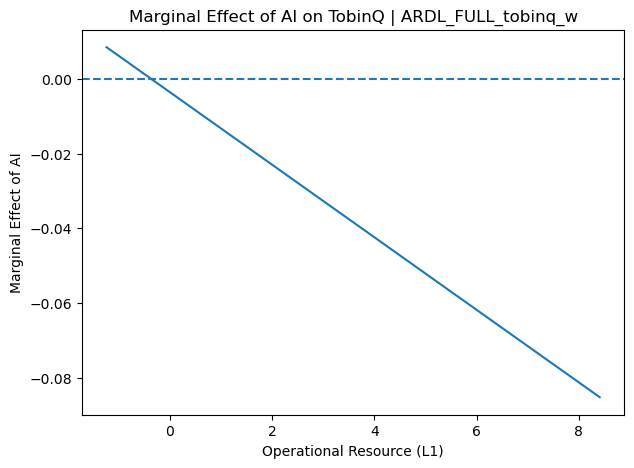

In [17]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from linearmodels.panel import PanelOLS

# =========================================================
# 0. Load
# =========================================================
file_path = "/Volumes/ORICO/Dissertation/output/panel_PCA_AI_PreAI_ready_v3.xlsx"
df = pd.read_excel(file_path)
df = df.sort_values(["gvkey", "year"]).copy()

# =========================================================
# 1. Main DV setup
# =========================================================
if "asinh_gop" not in df.columns and "gop" in df.columns:
    df["asinh_gop"] = np.arcsinh(df["gop"])

if "asinh_ni_dv" not in df.columns and "ni_dv" in df.columns:
    df["asinh_ni_dv"] = np.arcsinh(df["ni_dv"])

main_dvs = ["asinh_gop", "asinh_ni_dv", "tobinq_w"]
main_dvs = [dv for dv in main_dvs if dv in df.columns]

# =========================================================
# 2. Create lags
# =========================================================
# AI
if "AI_Focus_L1" not in df.columns:
    df["AI_Focus_L1"] = df.groupby("gvkey")["AI_Focus_per_million_words"].shift(1)
if "AI_Focus_L2" not in df.columns:
    df["AI_Focus_L2"] = df.groupby("gvkey")["AI_Focus_per_million_words"].shift(2)
if "AI_Focus_L3" not in df.columns:
    df["AI_Focus_L3"] = df.groupby("gvkey")["AI_Focus_per_million_words"].shift(3)

# PreAI
if "PreAI_Focus_L1" not in df.columns:
    df["PreAI_Focus_L1"] = df.groupby("gvkey")["PreAI_Focus_per_million_words"].shift(1)

# Resource bundles
for var in ["operational_pc1", "physical_pc1"]:
    if var in df.columns:
        for L in [1, 2, 3]:
            lag_name = f"{var}_L{L}"
            if lag_name not in df.columns:
                df[lag_name] = df.groupby("gvkey")[var].shift(L)

# intan_at
if "intan_at" not in df.columns and "intan" in df.columns and "at" in df.columns:
    df["intan_at"] = df["intan"] / df["at"]

if "intan_at" in df.columns:
    for L in [1, 2, 3]:
        lag_name = f"intan_at_L{L}"
        if lag_name not in df.columns:
            df[lag_name] = df.groupby("gvkey")["intan_at"].shift(L)

# market share
if "market_share_L1" not in df.columns and "market_share" in df.columns:
    df["market_share_L1"] = df.groupby("gvkey")["market_share"].shift(1)

# DV lags
for dv in main_dvs:
    if f"{dv}_L1" not in df.columns:
        df[f"{dv}_L1"] = df.groupby("gvkey")[dv].shift(1)

# =========================================================
# 3. Standardize variables for Z_INT_FULL
# =========================================================
def zscore_series(s):
    std = s.std(skipna=True)
    if pd.isna(std) or std == 0:
        return pd.Series(np.nan, index=s.index)
    return (s - s.mean(skipna=True)) / std

z_vars = ["AI_Focus_L1", "operational_pc1_L1", "physical_pc1_L1", "intan_at_L1"]
for v in z_vars:
    if v in df.columns:
        zname = f"z_{v}"
        if zname not in df.columns:
            df[zname] = zscore_series(df[v])

# standardized interactions
df["z_AI_operational_int"] = df["z_AI_Focus_L1"] * df["z_operational_pc1_L1"]
df["z_AI_physical_int"] = df["z_AI_Focus_L1"] * df["z_physical_pc1_L1"]
df["z_AI_intan_int"] = df["z_AI_Focus_L1"] * df["z_intan_at_L1"]

# raw interactions
df["AI_operational_int"] = df["AI_Focus_L1"] * df["operational_pc1_L1"]
df["AI_physical_int"] = df["AI_Focus_L1"] * df["physical_pc1_L1"]
df["AI_intan_int"] = df["AI_Focus_L1"] * df["intan_at_L1"]

# =========================================================
# 4. Clean and set panel index
# =========================================================
df = df.replace([np.inf, -np.inf], np.nan)
df = df.set_index(["gvkey", "year"])

# =========================================================
# 5. Spec definitions
# =========================================================
base_controls = [
    "size_ln_at_L1",
    "lev_L1",
    "liquidity_L1",
    "asset_turnover_L1",
    "z_score_L1",
    "distress_dummy_L1",
    "firm_hhi_L1",
    "market_share_L1"
]
base_controls = [c for c in base_controls if c in df.columns]

specs = {
    "Z_INT_FULL": [
        "z_AI_Focus_L1",
        "PreAI_Focus_L1",
        "z_operational_pc1_L1",
        "z_physical_pc1_L1",
        "z_intan_at_L1",
        "z_AI_operational_int",
        "z_AI_physical_int",
        "z_AI_intan_int",
    ] + base_controls,

    "LAG2_FULL": [
        "AI_Focus_L1", "AI_Focus_L2",
        "PreAI_Focus_L1",
        "operational_pc1_L1", "operational_pc1_L2",
        "physical_pc1_L1", "physical_pc1_L2",
        "intan_at_L1",
        "AI_operational_int",
        "AI_physical_int",
        "AI_intan_int",
    ] + base_controls,

    "ARDL_FULL": [
        "AI_Focus_L1", "AI_Focus_L2", "AI_Focus_L3",
        "PreAI_Focus_L1",
        "operational_pc1_L1", "operational_pc1_L2", "operational_pc1_L3",
        "physical_pc1_L1", "physical_pc1_L2", "physical_pc1_L3",
        "intan_at_L1",
        "AI_operational_int",
        "AI_physical_int",
        "AI_intan_int",
    ] + base_controls
}

for k in specs:
    specs[k] = [c for c in specs[k] if c in df.columns]

# =========================================================
# 6. Runner
# =========================================================
def run_model(data, dv, regressors, spec_name):
    dv_lag = f"{dv}_L1"
    needed = [dv, dv_lag] + regressors
    needed = [c for c in needed if c in data.columns]

    model_df = data[needed].dropna().copy()
    if len(model_df) < 100:
        print(f"Skipping {spec_name} | {dv}: too few observations ({len(model_df)})")
        return None

    y = model_df[dv]
    exog = sm.add_constant(model_df[[dv_lag] + regressors])

    model = PanelOLS(
        dependent=y,
        exog=exog,
        entity_effects=True,
        time_effects=True,
        drop_absorbed=True
    )

    result = model.fit(cov_type="clustered", cluster_entity=True)

    print("\n" + "=" * 110)
    print(f"{spec_name} | DV: {dv}")
    print("=" * 110)
    print(result.summary)

    return result, model_df, exog

# =========================================================
# 7. Run core 3x3 models and save results with clear names
# =========================================================
results = {}
model_dfs = {}
exogs = {}

for spec_name, regressors in specs.items():
    for dv in main_dvs:
        out = run_model(df, dv, regressors, spec_name)
        if out is not None:
            result_obj, model_df_obj, exog_obj = out
            key = f"{spec_name}_{dv}"
            results[key] = result_obj
            model_dfs[key] = model_df_obj
            exogs[key] = exog_obj

# examples of names you can use later:
# results["Z_INT_FULL_asinh_gop"]
# results["LAG2_FULL_asinh_ni_dv"]
# results["ARDL_FULL_tobinq_w"]

print("\nSaved result keys:")
print(list(results.keys()))

# =========================================================
# Joint tests
# =========================================================
def safe_wald(result_obj, hypothesis, label):
    print("\n" + "-" * 80)
    print(label)
    print("-" * 80)
    print(result_obj.wald_test(formula=hypothesis))

# AI lag joint test for ARDL models
ai_lag_hypothesis = [
    "AI_Focus_L1 = 0",
    "AI_Focus_L2 = 0",
    "AI_Focus_L3 = 0"
]

# interaction joint test for Z_INT_FULL
z_int_hypothesis = [
    "z_AI_operational_int = 0",
    "z_AI_physical_int = 0",
    "z_AI_intan_int = 0"
]

# raw interaction joint test for LAG2/ARDL
raw_int_hypothesis = [
    "AI_operational_int = 0",
    "AI_physical_int = 0",
    "AI_intan_int = 0"
]

# ARDL joint tests
if "ARDL_FULL_asinh_gop" in results:
    safe_wald(results["ARDL_FULL_asinh_gop"], ai_lag_hypothesis, "ARDL GOP | AI lag joint test")

if "ARDL_FULL_asinh_ni_dv" in results:
    safe_wald(results["ARDL_FULL_asinh_ni_dv"], ai_lag_hypothesis, "ARDL NI | AI lag joint test")

if "ARDL_FULL_tobinq_w" in results:
    safe_wald(results["ARDL_FULL_tobinq_w"], ai_lag_hypothesis, "ARDL TobinQ | AI lag joint test")

# interaction joint tests
if "Z_INT_FULL_asinh_gop" in results:
    safe_wald(results["Z_INT_FULL_asinh_gop"], z_int_hypothesis, "Z-INT GOP | interaction joint test")

if "Z_INT_FULL_asinh_ni_dv" in results:
    safe_wald(results["Z_INT_FULL_asinh_ni_dv"], z_int_hypothesis, "Z-INT NI | interaction joint test")

if "Z_INT_FULL_tobinq_w" in results:
    safe_wald(results["Z_INT_FULL_tobinq_w"], z_int_hypothesis, "Z-INT TobinQ | interaction joint test")

if "LAG2_FULL_tobinq_w" in results:
    safe_wald(results["LAG2_FULL_tobinq_w"], raw_int_hypothesis, "LAG2 TobinQ | interaction joint test")

if "ARDL_FULL_tobinq_w" in results:
    safe_wald(results["ARDL_FULL_tobinq_w"], raw_int_hypothesis, "ARDL TobinQ | interaction joint test")

# =========================================================
# 9. Long-run effects for ARDL
# =========================================================
def compute_long_run_ai(result_obj, dv_name):
    beta_dv = result_obj.params.get(f"{dv_name}_L1", np.nan)
    beta1 = result_obj.params.get("AI_Focus_L1", 0.0)
    beta2 = result_obj.params.get("AI_Focus_L2", 0.0)
    beta3 = result_obj.params.get("AI_Focus_L3", 0.0)

    if pd.isna(beta_dv) or (1 - beta_dv) == 0:
        return np.nan

    return (beta1 + beta2 + beta3) / (1 - beta_dv)

for dv in main_dvs:
    key = f"ARDL_FULL_{dv}"
    if key in results:
        lr = compute_long_run_ai(results[key], dv)
        print(f"\nLong-run AI effect | {dv}: {lr}")

# =========================================================
# 10. Marginal effect for TobinQ
# =========================================================
import matplotlib.pyplot as plt

# LAG2 or ARDL TobinQ 중 하나 사용
target_key = None
if "ARDL_FULL_tobinq_w" in results:
    target_key = "ARDL_FULL_tobinq_w"
elif "LAG2_FULL_tobinq_w" in results:
    target_key = "LAG2_FULL_tobinq_w"

if target_key is not None:
    res = results[target_key]
    model_df = model_dfs[target_key]

    beta_ai = res.params.get("AI_Focus_L1", 0.0)
    beta_int = res.params.get("AI_operational_int", 0.0)

    oper_range = np.linspace(
        model_df["operational_pc1_L1"].min(),
        model_df["operational_pc1_L1"].max(),
        50
    )

    marginal_effect = beta_ai + beta_int * oper_range

    plt.figure(figsize=(7, 5))
    plt.plot(oper_range, marginal_effect)
    plt.axhline(0, linestyle="--")
    plt.xlabel("Operational Resource (L1)")
    plt.ylabel("Marginal Effect of AI")
    plt.title(f"Marginal Effect of AI on TobinQ | {target_key}")
    plt.show()

Using intangible column: intan_raw

Z_INT_FULL | DV: asinh_gop
                          PanelOLS Estimation Summary                           
Dep. Variable:              asinh_gop   R-squared:                        0.1510
Estimator:                   PanelOLS   R-squared (Between):             -112.63
No. Observations:                1268   R-squared (Within):              -0.0288
Date:                Mon, Apr 20 2026   R-squared (Overall):             -30.678
Time:                        22:32:13   Log-likelihood                   -2103.7
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      11.786
Entities:                         109   P-value                           0.0000
Avg Obs:                       11.633   Distribution:                 F(17,1127)
Min Obs:                       1.0000                                           
Max Obs:                       49.000   F-stat

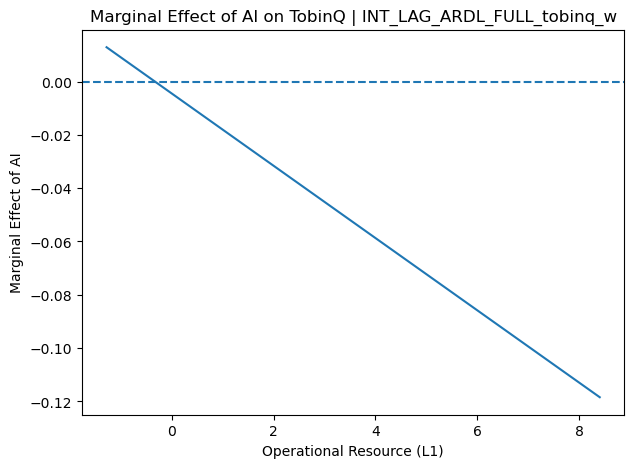

In [20]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from linearmodels.panel import PanelOLS
import matplotlib.pyplot as plt

# =========================================================
# 0. LOAD DATA
# =========================================================
file_path = "/Volumes/ORICO/Dissertation/output/panel_PCA_AI_PreAI_ready_v3_with_newsroom.xlsx"
df = pd.read_excel(file_path)

# sort
df = df.sort_values(["gvkey", "year"]).copy()

# =========================================================
# 1. BASIC DV CONSTRUCTION
# =========================================================
if "asinh_gop" not in df.columns and "gop" in df.columns:
    df["asinh_gop"] = np.arcsinh(df["gop"])

if "asinh_ni_dv" not in df.columns and "ni_dv" in df.columns:
    df["asinh_ni_dv"] = np.arcsinh(df["ni_dv"])

main_dvs = ["asinh_gop", "asinh_ni_dv", "tobinq_w"]
main_dvs = [dv for dv in main_dvs if dv in df.columns]

# =========================================================
# 2. RECONSTRUCT AT FROM size_ln_at
# =========================================================
# Assumption: size_ln_at = ln(at)

if "size_ln_at" in df.columns:
    df["at_reconstructed"] = np.exp(df["size_ln_at"])
elif "size_ln_at_L1" in df.columns:
    # L1만 있으면 raw at를 복원할 수 없으므로 stop
    raise KeyError("size_ln_at는 없고 size_ln_at_L1만 있습니다. raw intan_at 생성에는 size_ln_at가 필요합니다.")
else:
    raise KeyError("size_ln_at 컬럼이 없습니다.")

# =========================================================
# 3. DETECT INTANGIBLE RAW COLUMN
# =========================================================
possible_intan_cols = [
    "intan_raw", "INTAN_RAW",
    "intan", "INTAN",
    "intan_w", "INTAN_W"
]

intan_col = None
for c in possible_intan_cols:
    if c in df.columns:
        intan_col = c
        break

if intan_col is None:
    raise KeyError("intan raw 컬럼을 찾지 못했습니다.")

# create intan_at raw if not already present
if "intan_at" not in df.columns:
    df["intan_at"] = df[intan_col] / df["at_reconstructed"]

# clean inf
df = df.replace([np.inf, -np.inf], np.nan)

print(f"Using intangible column: {intan_col}")

# =========================================================
# 4. GENERIC LAG FUNCTION
# =========================================================
def make_lags(data, group_col, var_list, lags=(1, 2, 3)):
    for var in var_list:
        if var in data.columns:
            for L in lags:
                lag_name = f"{var}_L{L}"
                if lag_name not in data.columns:
                    data[lag_name] = data.groupby(group_col)[var].shift(L)
    return data

# =========================================================
# 5. CREATE ALL LAGS
# =========================================================
lag_vars = [
    "AI_Focus_per_million_words",
    "PreAI_Focus_per_million_words",
    "operational_pc1",
    "physical_pc1",
    "intan_at",
    "market_share"
] + main_dvs

df = make_lags(df, "gvkey", lag_vars, lags=(1, 2, 3))

# rename AI lag columns
rename_map = {}
for L in [1, 2, 3]:
    old_ai = f"AI_Focus_per_million_words_L{L}"
    old_pre = f"PreAI_Focus_per_million_words_L{L}"
    if old_ai in df.columns:
        rename_map[old_ai] = f"AI_Focus_L{L}"
    if old_pre in df.columns:
        rename_map[old_pre] = f"PreAI_Focus_L{L}"

df = df.rename(columns=rename_map)

# ensure DV lags
for dv in main_dvs:
    for L in [1, 2, 3]:
        lag_name = f"{dv}_L{L}"
        if lag_name not in df.columns and dv in df.columns:
            df[lag_name] = df.groupby("gvkey")[dv].shift(L)

# =========================================================
# 6. STANDARDIZATION FUNCTION
# =========================================================
def zscore_series(s):
    std = s.std(skipna=True)
    if pd.isna(std) or std == 0:
        return pd.Series(np.nan, index=s.index)
    return (s - s.mean(skipna=True)) / std

z_vars = [
    "AI_Focus_L1",
    "operational_pc1_L1",
    "physical_pc1_L1",
    "intan_at_L1"
]

for v in z_vars:
    if v in df.columns:
        zname = f"z_{v}"
        if zname not in df.columns:
            df[zname] = zscore_series(df[v])

# =========================================================
# 7. STANDARDIZED INTERACTIONS
# =========================================================
df["z_AI_operational_int"] = df["z_AI_Focus_L1"] * df["z_operational_pc1_L1"]
df["z_AI_physical_int"] = df["z_AI_Focus_L1"] * df["z_physical_pc1_L1"]
df["z_AI_intan_int"] = df["z_AI_Focus_L1"] * df["z_intan_at_L1"]

# =========================================================
# 8. RAW INTERACTIONS (L1)
# =========================================================
df["AI_operational_int"] = df["AI_Focus_L1"] * df["operational_pc1_L1"]
df["AI_physical_int"] = df["AI_Focus_L1"] * df["physical_pc1_L1"]
df["AI_intan_int"] = df["AI_Focus_L1"] * df["intan_at_L1"]

# =========================================================
# 9. LAGGED INTERACTIONS
#    AI_L1/L2/L3 × Resource_L1
# =========================================================
for L in [1, 2, 3]:
    ai_var = f"AI_Focus_L{L}"

    df[f"AI_L{L}_oper_int"] = df[ai_var] * df["operational_pc1_L1"]
    df[f"AI_L{L}_phys_int"] = df[ai_var] * df["physical_pc1_L1"]
    df[f"AI_L{L}_intan_int"] = df[ai_var] * df["intan_at_L1"]

# optional: if you want full intan lag interactions too
for ai_lag in [1, 2, 3]:
    for intan_lag in [1, 2, 3]:
        ai_var = f"AI_Focus_L{ai_lag}"
        intan_var = f"intan_at_L{intan_lag}"
        new_var = f"AI_L{ai_lag}_intan_L{intan_lag}_int"
        if ai_var in df.columns and intan_var in df.columns:
            df[new_var] = df[ai_var] * df[intan_var]

# =========================================================
# 10. FINAL CLEAN
# =========================================================
df = df.replace([np.inf, -np.inf], np.nan)

# panel index
df = df.set_index(["gvkey", "year"])

# =========================================================
# 11. CONTROLS
# =========================================================
base_controls = [
    "size_ln_at_L1",
    "lev_L1",
    "liquidity_L1",
    "asset_turnover_L1",
    "z_score_L1",
    "distress_dummy_L1",
    "firm_hhi_L1",
    "market_share_L1"
]
base_controls = [c for c in base_controls if c in df.columns]

# =========================================================
# 12. MODEL SPECS
# =========================================================
specs = {
    "Z_INT_FULL": [
        "z_AI_Focus_L1",
        "PreAI_Focus_L1",
        "z_operational_pc1_L1",
        "z_physical_pc1_L1",
        "z_intan_at_L1",
        "z_AI_operational_int",
        "z_AI_physical_int",
        "z_AI_intan_int",
    ] + base_controls,

    "LAG2_FULL": [
        "AI_Focus_L1", "AI_Focus_L2",
        "PreAI_Focus_L1",
        "operational_pc1_L1", "operational_pc1_L2",
        "physical_pc1_L1", "physical_pc1_L2",
        "intan_at_L1", "intan_at_L2",
        "AI_operational_int",
        "AI_physical_int",
        "AI_intan_int",
    ] + base_controls,

    "ARDL_FULL": [
        "AI_Focus_L1", "AI_Focus_L2", "AI_Focus_L3",
        "PreAI_Focus_L1",
        "operational_pc1_L1", "operational_pc1_L2", "operational_pc1_L3",
        "physical_pc1_L1", "physical_pc1_L2", "physical_pc1_L3",
        "intan_at_L1", "intan_at_L2", "intan_at_L3",
        "AI_operational_int",
        "AI_physical_int",
        "AI_intan_int",
    ] + base_controls,

    # lagged interaction model
    "INT_LAG_ARDL_FULL": [
        "AI_Focus_L1", "AI_Focus_L2", "AI_Focus_L3",
        "PreAI_Focus_L1",
        "operational_pc1_L1",
        "physical_pc1_L1",
        "intan_at_L1",

        "AI_L1_oper_int", "AI_L2_oper_int", "AI_L3_oper_int",
        "AI_L1_phys_int", "AI_L2_phys_int", "AI_L3_phys_int",
        "AI_L1_intan_int", "AI_L2_intan_int", "AI_L3_intan_int",
    ] + base_controls
}

# actual existing columns only
for k in specs:
    specs[k] = [c for c in specs[k] if c in df.columns]

# =========================================================
# 13. RUNNER
# =========================================================
def run_model(data, dv, regressors, spec_name):
    dv_lag = f"{dv}_L1"
    needed = [dv, dv_lag] + regressors
    needed = [c for c in needed if c in data.columns]

    model_df = data[needed].dropna().copy()

    if len(model_df) < 100:
        print(f"Skipping {spec_name} | {dv}: too few observations ({len(model_df)})")
        return None

    y = model_df[dv]
    exog = sm.add_constant(model_df[[dv_lag] + regressors])

    model = PanelOLS(
        dependent=y,
        exog=exog,
        entity_effects=True,
        time_effects=True,
        drop_absorbed=True
    )

    result = model.fit(cov_type="clustered", cluster_entity=True)

    print("\n" + "=" * 120)
    print(f"{spec_name} | DV: {dv}")
    print("=" * 120)
    print(result.summary)

    return result, model_df, exog

# =========================================================
# 14. RUN ALL MODELS
# =========================================================
results = {}
model_dfs = {}
exogs = {}
summary_rows = []

for spec_name, regressors in specs.items():
    for dv in main_dvs:
        out = run_model(df, dv, regressors, spec_name)
        if out is None:
            continue

        result_obj, model_df_obj, exog_obj = out
        key = f"{spec_name}_{dv}"

        results[key] = result_obj
        model_dfs[key] = model_df_obj
        exogs[key] = exog_obj

        row = {
            "Spec": spec_name,
            "DV": dv,
            "N": result_obj.nobs,
            "R2_within": result_obj.rsquared_within,
            "R2_overall": result_obj.rsquared_overall,
            "DV_L1_coef": result_obj.params.get(f"{dv}_L1", np.nan),
            "DV_L1_p": result_obj.pvalues.get(f"{dv}_L1", np.nan),
        }

        keep_vars = [
            "z_AI_Focus_L1",
            "AI_Focus_L1", "AI_Focus_L2", "AI_Focus_L3",
            "PreAI_Focus_L1",
            "z_AI_operational_int", "z_AI_physical_int", "z_AI_intan_int",
            "AI_operational_int", "AI_physical_int", "AI_intan_int",
            "AI_L1_oper_int", "AI_L2_oper_int", "AI_L3_oper_int",
            "AI_L1_phys_int", "AI_L2_phys_int", "AI_L3_phys_int",
            "AI_L1_intan_int", "AI_L2_intan_int", "AI_L3_intan_int"
        ]

        for var in keep_vars:
            row[f"{var}_coef"] = result_obj.params.get(var, np.nan)
            row[f"{var}_p"] = result_obj.pvalues.get(var, np.nan)

        summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows).sort_values(["DV", "Spec"]).reset_index(drop=True)

print("\nSaved result keys:")
print(list(results.keys()))
print("\nSummary table:")
print(summary_df)

summary_df.to_excel("all_specs_summary_with_intan_lags.xlsx", index=False)

# =========================================================
# 15. JOINT TESTS
# =========================================================
def safe_wald(result_obj, hypothesis, label):
    print("\n" + "-" * 90)
    print(label)
    print("-" * 90)
    print(result_obj.wald_test(formula=hypothesis))

ai_lag_hypothesis = [
    "AI_Focus_L1 = 0",
    "AI_Focus_L2 = 0",
    "AI_Focus_L3 = 0"
]

z_int_hypothesis = [
    "z_AI_operational_int = 0",
    "z_AI_physical_int = 0",
    "z_AI_intan_int = 0"
]

raw_int_hypothesis = [
    "AI_operational_int = 0",
    "AI_physical_int = 0",
    "AI_intan_int = 0"
]

lagged_int_hypothesis = [
    "AI_L1_oper_int = 0",
    "AI_L2_oper_int = 0",
    "AI_L3_oper_int = 0",
    "AI_L1_phys_int = 0",
    "AI_L2_phys_int = 0",
    "AI_L3_phys_int = 0",
    "AI_L1_intan_int = 0",
    "AI_L2_intan_int = 0",
    "AI_L3_intan_int = 0"
]

for dv in main_dvs:
    k = f"ARDL_FULL_{dv}"
    if k in results:
        safe_wald(results[k], ai_lag_hypothesis, f"ARDL {dv} | AI lag joint test")

for dv in main_dvs:
    k = f"Z_INT_FULL_{dv}"
    if k in results:
        safe_wald(results[k], z_int_hypothesis, f"Z_INT {dv} | interaction joint test")

for dv in main_dvs:
    k = f"LAG2_FULL_{dv}"
    if k in results:
        safe_wald(results[k], raw_int_hypothesis, f"LAG2 {dv} | interaction joint test")

for dv in main_dvs:
    k = f"INT_LAG_ARDL_FULL_{dv}"
    if k in results:
        safe_wald(results[k], lagged_int_hypothesis, f"INT_LAG_ARDL {dv} | lagged interaction joint test")

# =========================================================
# 16. LONG-RUN EFFECTS
# =========================================================
def compute_long_run_ai(result_obj, dv_name):
    beta_dv = result_obj.params.get(f"{dv_name}_L1", np.nan)
    beta1 = result_obj.params.get("AI_Focus_L1", 0.0)
    beta2 = result_obj.params.get("AI_Focus_L2", 0.0)
    beta3 = result_obj.params.get("AI_Focus_L3", 0.0)

    if pd.isna(beta_dv) or (1 - beta_dv) == 0:
        return np.nan

    return (beta1 + beta2 + beta3) / (1 - beta_dv)

for dv in main_dvs:
    key = f"ARDL_FULL_{dv}"
    if key in results:
        lr = compute_long_run_ai(results[key], dv)
        print(f"\nLong-run AI effect | {dv}: {lr}")

# =========================================================
# 17. OPTIONAL: TOBINQ MARGINAL EFFECT PLOT
# =========================================================
target_key = None
if "INT_LAG_ARDL_FULL_tobinq_w" in results:
    target_key = "INT_LAG_ARDL_FULL_tobinq_w"
elif "ARDL_FULL_tobinq_w" in results:
    target_key = "ARDL_FULL_tobinq_w"
elif "LAG2_FULL_tobinq_w" in results:
    target_key = "LAG2_FULL_tobinq_w"

if target_key is not None:
    res = results[target_key]
    model_df = model_dfs[target_key]

    beta_ai = res.params.get("AI_Focus_L1", 0.0)
    beta_int = res.params.get("AI_L1_oper_int", res.params.get("AI_operational_int", 0.0))

    oper_range = np.linspace(
        model_df["operational_pc1_L1"].min(),
        model_df["operational_pc1_L1"].max(),
        50
    )

    marginal_effect = beta_ai + beta_int * oper_range

    plt.figure(figsize=(7, 5))
    plt.plot(oper_range, marginal_effect)
    plt.axhline(0, linestyle="--")
    plt.xlabel("Operational Resource (L1)")
    plt.ylabel("Marginal Effect of AI")
    plt.title(f"Marginal Effect of AI on TobinQ | {target_key}")
    plt.show()

In [21]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from linearmodels.panel import PanelOLS

# =========================================================
# 0. df는 이미 만들어져 있고, MultiIndex [gvkey, year]라고 가정
#    혹시 아니면 아래 두 줄 실행
# =========================================================
# df = df.sort_values(["gvkey", "year"]).copy()
# df = df.set_index(["gvkey", "year"])

# =========================================================
# 1. 필요한 lag 컬럼 존재 확인
# =========================================================
required_base = [
    "AI_Focus_L1", "AI_Focus_L2", "AI_Focus_L3",
    "operational_pc1_L1", "operational_pc1_L2", "operational_pc1_L3",
    "physical_pc1_L1", "physical_pc1_L2", "physical_pc1_L3",
    "intan_at_L1", "intan_at_L2", "intan_at_L3"
]

missing_base = [c for c in required_base if c not in df.columns]
print("Missing base columns:", missing_base)

# =========================================================
# 2. 동일 시차 매칭 interaction 생성
#    AI_L1 × resource_L1
#    AI_L2 × resource_L2
#    AI_L3 × resource_L3
# =========================================================

# operational
if all(c in df.columns for c in ["AI_Focus_L1", "operational_pc1_L1"]):
    df["AI_L1_operL1_int"] = df["AI_Focus_L1"] * df["operational_pc1_L1"]
if all(c in df.columns for c in ["AI_Focus_L2", "operational_pc1_L2"]):
    df["AI_L2_operL2_int"] = df["AI_Focus_L2"] * df["operational_pc1_L2"]
if all(c in df.columns for c in ["AI_Focus_L3", "operational_pc1_L3"]):
    df["AI_L3_operL3_int"] = df["AI_Focus_L3"] * df["operational_pc1_L3"]

# physical
if all(c in df.columns for c in ["AI_Focus_L1", "physical_pc1_L1"]):
    df["AI_L1_physL1_int"] = df["AI_Focus_L1"] * df["physical_pc1_L1"]
if all(c in df.columns for c in ["AI_Focus_L2", "physical_pc1_L2"]):
    df["AI_L2_physL2_int"] = df["AI_Focus_L2"] * df["physical_pc1_L2"]
if all(c in df.columns for c in ["AI_Focus_L3", "physical_pc1_L3"]):
    df["AI_L3_physL3_int"] = df["AI_Focus_L3"] * df["physical_pc1_L3"]

# intangible
if all(c in df.columns for c in ["AI_Focus_L1", "intan_at_L1"]):
    df["AI_L1_intanL1_int"] = df["AI_Focus_L1"] * df["intan_at_L1"]
if all(c in df.columns for c in ["AI_Focus_L2", "intan_at_L2"]):
    df["AI_L2_intanL2_int"] = df["AI_Focus_L2"] * df["intan_at_L2"]
if all(c in df.columns for c in ["AI_Focus_L3", "intan_at_L3"]):
    df["AI_L3_intanL3_int"] = df["AI_Focus_L3"] * df["intan_at_L3"]

# =========================================================
# 3. Controls
# =========================================================
base_controls = [
    "size_ln_at_L1",
    "lev_L1",
    "liquidity_L1",
    "asset_turnover_L1",
    "z_score_L1",
    "distress_dummy_L1",
    "firm_hhi_L1",
    "market_share_L1"
]
base_controls = [c for c in base_controls if c in df.columns]

# =========================================================
# 4. 새 specification
# =========================================================

# 풀버전: resource lag 자체도 L1-L3까지 통제
matched_lag_int_full = [
    "AI_Focus_L1", "AI_Focus_L2", "AI_Focus_L3",
    "PreAI_Focus_L1",

    "operational_pc1_L1", "operational_pc1_L2", "operational_pc1_L3",
    "physical_pc1_L1", "physical_pc1_L2", "physical_pc1_L3",
    "intan_at_L1", "intan_at_L2", "intan_at_L3",

    "AI_L1_operL1_int", "AI_L2_operL2_int", "AI_L3_operL3_int",
    "AI_L1_physL1_int", "AI_L2_physL2_int", "AI_L3_physL3_int",
    "AI_L1_intanL1_int", "AI_L2_intanL2_int", "AI_L3_intanL3_int",
] + base_controls

# 컴팩트 버전: resource lag는 L1만 두고, interaction만 matched lags
matched_lag_int_compact = [
    "AI_Focus_L1", "AI_Focus_L2", "AI_Focus_L3",
    "PreAI_Focus_L1",

    "operational_pc1_L1",
    "physical_pc1_L1",
    "intan_at_L1",

    "AI_L1_operL1_int", "AI_L2_operL2_int", "AI_L3_operL3_int",
    "AI_L1_physL1_int", "AI_L2_physL2_int", "AI_L3_physL3_int",
    "AI_L1_intanL1_int", "AI_L2_intanL2_int", "AI_L3_intanL3_int",
] + base_controls

matched_lag_int_full = [c for c in matched_lag_int_full if c in df.columns]
matched_lag_int_compact = [c for c in matched_lag_int_compact if c in df.columns]

new_specs = {
    "MATCHED_LAG_INT_FULL": matched_lag_int_full,
    "MATCHED_LAG_INT_COMPACT": matched_lag_int_compact
}

# =========================================================
# 5. DV 목록
# =========================================================
main_dvs = [dv for dv in ["asinh_gop", "asinh_ni_dv", "tobinq_w"] if dv in df.columns]

# =========================================================
# 6. Runner
# =========================================================
def run_model(data, dv, regressors, spec_name):
    dv_lag = f"{dv}_L1"
    needed = [dv, dv_lag] + regressors
    needed = [c for c in needed if c in data.columns]

    model_df = data[needed].replace([np.inf, -np.inf], np.nan).dropna().copy()

    if len(model_df) < 100:
        print(f"Skipping {spec_name} | {dv}: too few observations ({len(model_df)})")
        return None

    y = model_df[dv]
    exog = sm.add_constant(model_df[[dv_lag] + regressors])

    model = PanelOLS(
        dependent=y,
        exog=exog,
        entity_effects=True,
        time_effects=True,
        drop_absorbed=True
    )

    result = model.fit(cov_type="clustered", cluster_entity=True)

    print("\n" + "=" * 120)
    print(f"{spec_name} | DV: {dv}")
    print("=" * 120)
    print(result.summary)

    return result, model_df

# =========================================================
# 7. Run
# =========================================================
matched_results = {}
matched_summary_rows = []

for spec_name, regressors in new_specs.items():
    for dv in main_dvs:
        out = run_model(df, dv, regressors, spec_name)
        if out is None:
            continue

        result_obj, model_df_obj = out
        key = f"{spec_name}_{dv}"
        matched_results[key] = result_obj

        row = {
            "Spec": spec_name,
            "DV": dv,
            "N": result_obj.nobs,
            "R2_within": result_obj.rsquared_within,
            "R2_overall": result_obj.rsquared_overall,
            "DV_L1_coef": result_obj.params.get(f"{dv}_L1", np.nan),
            "DV_L1_p": result_obj.pvalues.get(f"{dv}_L1", np.nan),

            "AI_L1_operL1_int_coef": result_obj.params.get("AI_L1_operL1_int", np.nan),
            "AI_L1_operL1_int_p": result_obj.pvalues.get("AI_L1_operL1_int", np.nan),
            "AI_L2_operL2_int_coef": result_obj.params.get("AI_L2_operL2_int", np.nan),
            "AI_L2_operL2_int_p": result_obj.pvalues.get("AI_L2_operL2_int", np.nan),
            "AI_L3_operL3_int_coef": result_obj.params.get("AI_L3_operL3_int", np.nan),
            "AI_L3_operL3_int_p": result_obj.pvalues.get("AI_L3_operL3_int", np.nan),

            "AI_L1_physL1_int_coef": result_obj.params.get("AI_L1_physL1_int", np.nan),
            "AI_L1_physL1_int_p": result_obj.pvalues.get("AI_L1_physL1_int", np.nan),
            "AI_L2_physL2_int_coef": result_obj.params.get("AI_L2_physL2_int", np.nan),
            "AI_L2_physL2_int_p": result_obj.pvalues.get("AI_L2_physL2_int", np.nan),
            "AI_L3_physL3_int_coef": result_obj.params.get("AI_L3_physL3_int", np.nan),
            "AI_L3_physL3_int_p": result_obj.pvalues.get("AI_L3_physL3_int", np.nan),

            "AI_L1_intanL1_int_coef": result_obj.params.get("AI_L1_intanL1_int", np.nan),
            "AI_L1_intanL1_int_p": result_obj.pvalues.get("AI_L1_intanL1_int", np.nan),
            "AI_L2_intanL2_int_coef": result_obj.params.get("AI_L2_intanL2_int", np.nan),
            "AI_L2_intanL2_int_p": result_obj.pvalues.get("AI_L2_intanL2_int", np.nan),
            "AI_L3_intanL3_int_coef": result_obj.params.get("AI_L3_intanL3_int", np.nan),
            "AI_L3_intanL3_int_p": result_obj.pvalues.get("AI_L3_intanL3_int", np.nan),
        }
        matched_summary_rows.append(row)

matched_summary_df = pd.DataFrame(matched_summary_rows).sort_values(["DV", "Spec"]).reset_index(drop=True)
print("\nMatched-lag summary:")
print(matched_summary_df)
matched_summary_df.to_excel("matched_lag_interaction_summary.xlsx", index=False)

# =========================================================
# 8. Joint tests
# =========================================================
def safe_wald(result_obj, hypothesis, label):
    print("\n" + "-" * 90)
    print(label)
    print("-" * 90)
    print(result_obj.wald_test(formula=hypothesis))

matched_oper_hyp = [
    "AI_L1_operL1_int = 0",
    "AI_L2_operL2_int = 0",
    "AI_L3_operL3_int = 0",
]

matched_phys_hyp = [
    "AI_L1_physL1_int = 0",
    "AI_L2_physL2_int = 0",
    "AI_L3_physL3_int = 0",
]

matched_intan_hyp = [
    "AI_L1_intanL1_int = 0",
    "AI_L2_intanL2_int = 0",
    "AI_L3_intanL3_int = 0",
]

matched_all_hyp = matched_oper_hyp + matched_phys_hyp + matched_intan_hyp

for dv in main_dvs:
    for spec_name in ["MATCHED_LAG_INT_FULL", "MATCHED_LAG_INT_COMPACT"]:
        key = f"{spec_name}_{dv}"
        if key in matched_results:
            safe_wald(matched_results[key], matched_oper_hyp, f"{key} | matched operational interaction joint test")
            safe_wald(matched_results[key], matched_phys_hyp, f"{key} | matched physical interaction joint test")
            safe_wald(matched_results[key], matched_intan_hyp, f"{key} | matched intangible interaction joint test")
            safe_wald(matched_results[key], matched_all_hyp, f"{key} | matched all interaction joint test")

Missing base columns: []

MATCHED_LAG_INT_FULL | DV: asinh_gop
                          PanelOLS Estimation Summary                           
Dep. Variable:              asinh_gop   R-squared:                        0.1328
Estimator:                   PanelOLS   R-squared (Between):             -82.796
No. Observations:                1063   R-squared (Within):              -0.0006
Date:                Mon, Apr 20 2026   R-squared (Overall):             -7.5528
Time:                        22:42:12   Log-likelihood                   -1765.3
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      4.5560
Entities:                          95   P-value                           0.0000
Avg Obs:                       11.189   Distribution:                  F(31,922)
Min Obs:                       1.0000                                           
Max Obs:                       47.000   F-stat

In [22]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from linearmodels.panel import PanelOLS

# =========================================================
# 0. PREP
# =========================================================
# df가 아직 index 설정 안 되어 있으면 아래 사용
# df = df.sort_values(["gvkey", "year"]).copy()
# df = df.set_index(["gvkey", "year"])

# =========================================================
# 1. Helper: create lag if missing
# =========================================================
def create_lag_if_missing(data, raw_col, base_name, lags=(1, 2, 3), group_level=0):
    """
    data: MultiIndex DataFrame indexed by [gvkey, year]
    raw_col: original column name
    base_name: desired lag prefix
    """
    if raw_col in data.columns:
        for L in lags:
            lag_col = f"{base_name}_L{L}"
            if lag_col not in data.columns:
                data[lag_col] = data.groupby(level=group_level)[raw_col].shift(L)

# =========================================================
# 2. PreAI lag generation
# =========================================================
# case 1: raw column exists
if "PreAI_Focus_per_million_words" in df.columns:
    create_lag_if_missing(df, "PreAI_Focus_per_million_words", "PreAI_Focus", lags=(1, 2, 3), group_level=0)

# case 2: L1 exists but L2/L3 missing and raw not present
# -> cannot reconstruct perfectly, so only proceed if raw exists
print("PreAI lag columns available:",
      [c for c in ["PreAI_Focus_L1", "PreAI_Focus_L2", "PreAI_Focus_L3"] if c in df.columns])

# =========================================================
# 3. Ensure matched interaction terms exist
# =========================================================
# operational matched interactions
if all(c in df.columns for c in ["AI_Focus_L1", "operational_pc1_L1"]) and "AI_L1_operL1_int" not in df.columns:
    df["AI_L1_operL1_int"] = df["AI_Focus_L1"] * df["operational_pc1_L1"]
if all(c in df.columns for c in ["AI_Focus_L2", "operational_pc1_L2"]) and "AI_L2_operL2_int" not in df.columns:
    df["AI_L2_operL2_int"] = df["AI_Focus_L2"] * df["operational_pc1_L2"]
if all(c in df.columns for c in ["AI_Focus_L3", "operational_pc1_L3"]) and "AI_L3_operL3_int" not in df.columns:
    df["AI_L3_operL3_int"] = df["AI_Focus_L3"] * df["operational_pc1_L3"]

# physical matched interactions
if all(c in df.columns for c in ["AI_Focus_L1", "physical_pc1_L1"]) and "AI_L1_physL1_int" not in df.columns:
    df["AI_L1_physL1_int"] = df["AI_Focus_L1"] * df["physical_pc1_L1"]
if all(c in df.columns for c in ["AI_Focus_L2", "physical_pc1_L2"]) and "AI_L2_physL2_int" not in df.columns:
    df["AI_L2_physL2_int"] = df["AI_Focus_L2"] * df["physical_pc1_L2"]
if all(c in df.columns for c in ["AI_Focus_L3", "physical_pc1_L3"]) and "AI_L3_physL3_int" not in df.columns:
    df["AI_L3_physL3_int"] = df["AI_Focus_L3"] * df["physical_pc1_L3"]

# intangible matched interactions
if all(c in df.columns for c in ["AI_Focus_L1", "intan_at_L1"]) and "AI_L1_intanL1_int" not in df.columns:
    df["AI_L1_intanL1_int"] = df["AI_Focus_L1"] * df["intan_at_L1"]
if all(c in df.columns for c in ["AI_Focus_L2", "intan_at_L2"]) and "AI_L2_intanL2_int" not in df.columns:
    df["AI_L2_intanL2_int"] = df["AI_Focus_L2"] * df["intan_at_L2"]
if all(c in df.columns for c in ["AI_Focus_L3", "intan_at_L3"]) and "AI_L3_intanL3_int" not in df.columns:
    df["AI_L3_intanL3_int"] = df["AI_Focus_L3"] * df["intan_at_L3"]

# =========================================================
# 4. Controls
# =========================================================
base_controls = [
    "size_ln_at_L1",
    "lev_L1",
    "liquidity_L1",
    "asset_turnover_L1",
    "z_score_L1",
    "distress_dummy_L1",
    "firm_hhi_L1",
    "market_share_L1"
]
base_controls = [c for c in base_controls if c in df.columns]

# =========================================================
# 5. Final specs
# =========================================================
# Main full matched-lag model with PreAI L1-L2
main_full_preai2 = [
    "AI_Focus_L1", "AI_Focus_L2", "AI_Focus_L3",
    "PreAI_Focus_L1", "PreAI_Focus_L2",

    "operational_pc1_L1", "operational_pc1_L2", "operational_pc1_L3",
    "physical_pc1_L1", "physical_pc1_L2", "physical_pc1_L3",
    "intan_at_L1", "intan_at_L2", "intan_at_L3",

    "AI_L1_operL1_int", "AI_L2_operL2_int", "AI_L3_operL3_int",
    "AI_L1_physL1_int", "AI_L2_physL2_int", "AI_L3_physL3_int",
    "AI_L1_intanL1_int", "AI_L2_intanL2_int", "AI_L3_intanL3_int",
] + base_controls

# robustness: PreAI L1-L3
main_full_preai3 = [
    "AI_Focus_L1", "AI_Focus_L2", "AI_Focus_L3",
    "PreAI_Focus_L1", "PreAI_Focus_L2", "PreAI_Focus_L3",

    "operational_pc1_L1", "operational_pc1_L2", "operational_pc1_L3",
    "physical_pc1_L1", "physical_pc1_L2", "physical_pc1_L3",
    "intan_at_L1", "intan_at_L2", "intan_at_L3",

    "AI_L1_operL1_int", "AI_L2_operL2_int", "AI_L3_operL3_int",
    "AI_L1_physL1_int", "AI_L2_physL2_int", "AI_L3_physL3_int",
    "AI_L1_intanL1_int", "AI_L2_intanL2_int", "AI_L3_intanL3_int",
] + base_controls

specs = {
    "MATCHED_LAG_INT_FULL_PREAI2": [c for c in main_full_preai2 if c in df.columns],
    "MATCHED_LAG_INT_FULL_PREAI3": [c for c in main_full_preai3 if c in df.columns],
}

# =========================================================
# 6. DVs
# =========================================================
main_dvs = [dv for dv in ["asinh_gop", "asinh_ni_dv", "tobinq_w"] if dv in df.columns]

# ensure lag DV exists
for dv in main_dvs:
    dv_lag = f"{dv}_L1"
    if dv_lag not in df.columns:
        raise KeyError(f"{dv_lag} is missing.")

# =========================================================
# 7. Runner
# =========================================================
def run_model(data, dv, regressors, spec_name):
    dv_lag = f"{dv}_L1"
    needed = [dv, dv_lag] + regressors
    needed = [c for c in needed if c in data.columns]

    model_df = data[needed].replace([np.inf, -np.inf], np.nan).dropna().copy()

    if len(model_df) < 100:
        print(f"Skipping {spec_name} | {dv}: too few observations ({len(model_df)})")
        return None

    y = model_df[dv]
    exog = sm.add_constant(model_df[[dv_lag] + regressors])

    model = PanelOLS(
        dependent=y,
        exog=exog,
        entity_effects=True,
        time_effects=True,
        drop_absorbed=True
    )

    result = model.fit(cov_type="clustered", cluster_entity=True)

    print("\n" + "=" * 120)
    print(f"{spec_name} | DV: {dv}")
    print("=" * 120)
    print(result.summary)

    return result, model_df

# =========================================================
# 8. Run all
# =========================================================
final_results = {}
final_summary = []

for spec_name, regressors in specs.items():
    for dv in main_dvs:
        out = run_model(df, dv, regressors, spec_name)
        if out is None:
            continue

        result_obj, model_df_obj = out
        key = f"{spec_name}_{dv}"
        final_results[key] = result_obj

        row = {
            "Spec": spec_name,
            "DV": dv,
            "N": result_obj.nobs,
            "R2_within": result_obj.rsquared_within,
            "R2_overall": result_obj.rsquared_overall,
            "DV_L1_coef": result_obj.params.get(f"{dv}_L1", np.nan),
            "DV_L1_p": result_obj.pvalues.get(f"{dv}_L1", np.nan),

            "AI_L1_operL1_int_coef": result_obj.params.get("AI_L1_operL1_int", np.nan),
            "AI_L1_operL1_int_p": result_obj.pvalues.get("AI_L1_operL1_int", np.nan),
            "AI_L2_operL2_int_coef": result_obj.params.get("AI_L2_operL2_int", np.nan),
            "AI_L2_operL2_int_p": result_obj.pvalues.get("AI_L2_operL2_int", np.nan),
            "AI_L3_operL3_int_coef": result_obj.params.get("AI_L3_operL3_int", np.nan),
            "AI_L3_operL3_int_p": result_obj.pvalues.get("AI_L3_operL3_int", np.nan),

            "AI_L1_intanL1_int_coef": result_obj.params.get("AI_L1_intanL1_int", np.nan),
            "AI_L1_intanL1_int_p": result_obj.pvalues.get("AI_L1_intanL1_int", np.nan),
            "AI_L2_intanL2_int_coef": result_obj.params.get("AI_L2_intanL2_int", np.nan),
            "AI_L2_intanL2_int_p": result_obj.pvalues.get("AI_L2_intanL2_int", np.nan),
            "AI_L3_intanL3_int_coef": result_obj.params.get("AI_L3_intanL3_int", np.nan),
            "AI_L3_intanL3_int_p": result_obj.pvalues.get("AI_L3_intanL3_int", np.nan),
        }
        final_summary.append(row)

final_summary_df = pd.DataFrame(final_summary).sort_values(["DV", "Spec"]).reset_index(drop=True)
print("\nFinal summary:")
print(final_summary_df)
final_summary_df.to_excel("final_full_matched_lag_preai_summary.xlsx", index=False)

# =========================================================
# 9. Joint tests
# =========================================================
def safe_wald(result_obj, hypothesis, label):
    print("\n" + "-" * 90)
    print(label)
    print("-" * 90)
    print(result_obj.wald_test(formula=hypothesis))

oper_hyp = [
    "AI_L1_operL1_int = 0",
    "AI_L2_operL2_int = 0",
    "AI_L3_operL3_int = 0",
]

phys_hyp = [
    "AI_L1_physL1_int = 0",
    "AI_L2_physL2_int = 0",
    "AI_L3_physL3_int = 0",
]

intan_hyp = [
    "AI_L1_intanL1_int = 0",
    "AI_L2_intanL2_int = 0",
    "AI_L3_intanL3_int = 0",
]

all_hyp = oper_hyp + phys_hyp + intan_hyp

for key, result_obj in final_results.items():
    safe_wald(result_obj, oper_hyp, f"{key} | operational interaction joint test")
    safe_wald(result_obj, phys_hyp, f"{key} | physical interaction joint test")
    safe_wald(result_obj, intan_hyp, f"{key} | intangible interaction joint test")
    safe_wald(result_obj, all_hyp, f"{key} | all matched interaction joint test")

# =========================================================
# 10. Cumulative operational effect test for TobinQ
# =========================================================
for spec_name in ["MATCHED_LAG_INT_FULL_PREAI2", "MATCHED_LAG_INT_FULL_PREAI3"]:
    key = f"{spec_name}_tobinq_w"
    if key in final_results:
        res = final_results[key]

        print("\n" + "=" * 90)
        print(f"CUMULATIVE TEST | {key}")
        print("=" * 90)

        cum_test = res.wald_test(
            formula="AI_L1_operL1_int + AI_L2_operL2_int + AI_L3_operL3_int = 0"
        )
        print(cum_test)

        cum_coef = (
            res.params.get("AI_L1_operL1_int", 0.0)
            + res.params.get("AI_L2_operL2_int", 0.0)
            + res.params.get("AI_L3_operL3_int", 0.0)
        )
        print("Cumulative operational interaction coefficient:", round(cum_coef, 6))

PreAI lag columns available: ['PreAI_Focus_L1', 'PreAI_Focus_L2', 'PreAI_Focus_L3']

MATCHED_LAG_INT_FULL_PREAI2 | DV: asinh_gop
                          PanelOLS Estimation Summary                           
Dep. Variable:              asinh_gop   R-squared:                        0.1332
Estimator:                   PanelOLS   R-squared (Between):             -84.292
No. Observations:                1063   R-squared (Within):               0.0026
Date:                Mon, Apr 20 2026   R-squared (Overall):             -7.6962
Time:                        22:54:56   Log-likelihood                   -1765.1
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      4.4225
Entities:                          95   P-value                           0.0000
Avg Obs:                       11.189   Distribution:                  F(32,921)
Min Obs:                       1.0000                        

In [1]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from linearmodels.panel import PanelOLS

# =========================================================
# 0. LOAD DATA
# =========================================================
file_path = "/Volumes/ORICO/Dissertation/output/panel_PCA_AI_PreAI_ready_v3_with_newsroom.xlsx"
df = pd.read_excel(file_path)

# sort
df = df.sort_values(["gvkey", "year"]).copy()

print("Loaded shape:", df.shape)
print("First columns:", df.columns[:20].tolist())

# =========================================================
# 1. BASIC DV CONSTRUCTION
# =========================================================
if "asinh_gop" not in df.columns and "gop" in df.columns:
    df["asinh_gop"] = np.arcsinh(df["gop"])

if "asinh_ni_dv" not in df.columns and "ni_dv" in df.columns:
    df["asinh_ni_dv"] = np.arcsinh(df["ni_dv"])

main_dvs = ["asinh_gop", "asinh_ni_dv", "tobinq_w"]
main_dvs = [dv for dv in main_dvs if dv in df.columns]

print("DVs found:", main_dvs)

# =========================================================
# 2. RECONSTRUCT intan_at IF NEEDED
# =========================================================
# Assumption: size_ln_at = ln(at)
if "intan_at" not in df.columns:
    if "size_ln_at" in df.columns:
        df["at_reconstructed"] = np.exp(df["size_ln_at"])
    else:
        raise KeyError("size_ln_at 컬럼이 없습니다. intan_at 복원 불가")

    possible_intan_cols = [
        "intan_raw", "INTAN_RAW",
        "intan", "INTAN",
        "intan_w", "INTAN_W"
    ]

    intan_col = None
    for c in possible_intan_cols:
        if c in df.columns:
            intan_col = c
            break

    if intan_col is None:
        raise KeyError("intan raw 컬럼을 찾지 못했습니다.")

    df["intan_at"] = df[intan_col] / df["at_reconstructed"]
    print(f"Created intan_at using {intan_col} / exp(size_ln_at)")
else:
    print("intan_at already exists.")

# clean inf
df = df.replace([np.inf, -np.inf], np.nan)

# =========================================================
# 3. GENERIC LAG FUNCTION
# =========================================================
def make_lags(data, group_col, var_list, lags=(1, 2, 3)):
    for var in var_list:
        if var in data.columns:
            for L in lags:
                lag_name = f"{var}_L{L}"
                if lag_name not in data.columns:
                    data[lag_name] = data.groupby(group_col)[var].shift(L)
    return data

# =========================================================
# 4. CREATE LAGS
# =========================================================
lag_vars = [
    # 10-K
    "AI_Focus_per_million_words",
    "PreAI_Focus_per_million_words",
    # Newsroom
    "AI_News_Focus_per_million_words",
    "PreAI_News_Focus_per_million_words",
    # Resources
    "operational_pc1",
    "physical_pc1",
    "intan_at",
    "market_share",
    # DVs
] + main_dvs

df = make_lags(df, "gvkey", lag_vars, lags=(1, 2, 3))

# Rename lagged 10-K AI
rename_map = {}
for L in [1, 2, 3]:
    if f"AI_Focus_per_million_words_L{L}" in df.columns:
        rename_map[f"AI_Focus_per_million_words_L{L}"] = f"AI_Focus_L{L}"
    if f"PreAI_Focus_per_million_words_L{L}" in df.columns:
        rename_map[f"PreAI_Focus_per_million_words_L{L}"] = f"PreAI_Focus_L{L}"

    if f"AI_News_Focus_per_million_words_L{L}" in df.columns:
        rename_map[f"AI_News_Focus_per_million_words_L{L}"] = f"AI_News_L{L}"
    if f"PreAI_News_Focus_per_million_words_L{L}" in df.columns:
        rename_map[f"PreAI_News_Focus_per_million_words_L{L}"] = f"PreAI_News_L{L}"

df = df.rename(columns=rename_map)

# Ensure DV lags
for dv in main_dvs:
    for L in [1, 2, 3]:
        lag_name = f"{dv}_L{L}"
        if lag_name not in df.columns and dv in df.columns:
            df[lag_name] = df.groupby("gvkey")[dv].shift(L)

# =========================================================
# 5. CREATE MATCHED INTERACTIONS
# =========================================================
# 10-K AI matched interactions
for L in [1, 2, 3]:
    ai_var = f"AI_Focus_L{L}"

    if ai_var in df.columns and f"operational_pc1_L{L}" in df.columns:
        df[f"AI_L{L}_operL{L}_int"] = df[ai_var] * df[f"operational_pc1_L{L}"]

    if ai_var in df.columns and f"physical_pc1_L{L}" in df.columns:
        df[f"AI_L{L}_physL{L}_int"] = df[ai_var] * df[f"physical_pc1_L{L}"]

    if ai_var in df.columns and f"intan_at_L{L}" in df.columns:
        df[f"AI_L{L}_intanL{L}_int"] = df[ai_var] * df[f"intan_at_L{L}"]

# Newsroom AI matched interactions
for L in [1, 2, 3]:
    ai_var = f"AI_News_L{L}"

    if ai_var in df.columns and f"operational_pc1_L{L}" in df.columns:
        df[f"AI_News_L{L}_operL{L}_int"] = df[ai_var] * df[f"operational_pc1_L{L}"]

    if ai_var in df.columns and f"physical_pc1_L{L}" in df.columns:
        df[f"AI_News_L{L}_physL{L}_int"] = df[ai_var] * df[f"physical_pc1_L{L}"]

    if ai_var in df.columns and f"intan_at_L{L}" in df.columns:
        df[f"AI_News_L{L}_intanL{L}_int"] = df[ai_var] * df[f"intan_at_L{L}"]

# =========================================================
# 6. FINAL CLEAN / PANEL INDEX
# =========================================================
df = df.replace([np.inf, -np.inf], np.nan)
df = df.set_index(["gvkey", "year"])

# =========================================================
# 7. CONTROLS
# =========================================================
base_controls = [
    "size_ln_at_L1",
    "lev_L1",
    "liquidity_L1",
    "asset_turnover_L1",
    "z_score_L1",
    "distress_dummy_L1",
    "firm_hhi_L1",
    "market_share_L1"
]
base_controls = [c for c in base_controls if c in df.columns]

print("Controls:", base_controls)

# =========================================================
# 8. SPECIFICATIONS
# =========================================================
# A. Newsroom only
news_only_spec = [
    "AI_News_L1", "AI_News_L2", "AI_News_L3",
    "PreAI_News_L1", "PreAI_News_L2"
] + base_controls

# B. 10-K + newsroom main effects
combined_spec = [
    "AI_Focus_L1", "AI_Focus_L2", "AI_Focus_L3",
    "PreAI_Focus_L1", "PreAI_Focus_L2",
    "AI_News_L1", "AI_News_L2", "AI_News_L3",
    "PreAI_News_L1", "PreAI_News_L2"
] + base_controls

# C. 10-K matched interaction benchmark
tenk_matched_full = [
    "AI_Focus_L1", "AI_Focus_L2", "AI_Focus_L3",
    "PreAI_Focus_L1", "PreAI_Focus_L2",
    "operational_pc1_L1", "operational_pc1_L2", "operational_pc1_L3",
    "physical_pc1_L1", "physical_pc1_L2", "physical_pc1_L3",
    "intan_at_L1", "intan_at_L2", "intan_at_L3",
    "AI_L1_operL1_int", "AI_L2_operL2_int", "AI_L3_operL3_int",
    "AI_L1_physL1_int", "AI_L2_physL2_int", "AI_L3_physL3_int",
    "AI_L1_intanL1_int", "AI_L2_intanL2_int", "AI_L3_intanL3_int",
] + base_controls

# D. Newsroom matched interaction full
news_matched_full = [
    "AI_News_L1", "AI_News_L2", "AI_News_L3",
    "PreAI_News_L1", "PreAI_News_L2",
    "operational_pc1_L1", "operational_pc1_L2", "operational_pc1_L3",
    "physical_pc1_L1", "physical_pc1_L2", "physical_pc1_L3",
    "intan_at_L1", "intan_at_L2", "intan_at_L3",
    "AI_News_L1_operL1_int", "AI_News_L2_operL2_int", "AI_News_L3_operL3_int",
    "AI_News_L1_physL1_int", "AI_News_L2_physL2_int", "AI_News_L3_physL3_int",
    "AI_News_L1_intanL1_int", "AI_News_L2_intanL2_int", "AI_News_L3_intanL3_int",
] + base_controls

# E. 10-K + newsroom matched interaction full
dual_matched_full = [
    "AI_Focus_L1", "AI_Focus_L2", "AI_Focus_L3",
    "PreAI_Focus_L1", "PreAI_Focus_L2",
    "AI_News_L1", "AI_News_L2", "AI_News_L3",
    "PreAI_News_L1", "PreAI_News_L2",
    "operational_pc1_L1", "operational_pc1_L2", "operational_pc1_L3",
    "physical_pc1_L1", "physical_pc1_L2", "physical_pc1_L3",
    "intan_at_L1", "intan_at_L2", "intan_at_L3",

    "AI_L1_operL1_int", "AI_L2_operL2_int", "AI_L3_operL3_int",
    "AI_L1_physL1_int", "AI_L2_physL2_int", "AI_L3_physL3_int",
    "AI_L1_intanL1_int", "AI_L2_intanL2_int", "AI_L3_intanL3_int",

    "AI_News_L1_operL1_int", "AI_News_L2_operL2_int", "AI_News_L3_operL3_int",
    "AI_News_L1_physL1_int", "AI_News_L2_physL2_int", "AI_News_L3_physL3_int",
    "AI_News_L1_intanL1_int", "AI_News_L2_intanL2_int", "AI_News_L3_intanL3_int",
] + base_controls

specs = {
    "NEWS_ONLY": news_only_spec,
    "COMBINED_MAIN": combined_spec,
    "TENK_MATCHED_FULL": tenk_matched_full,
    "NEWS_MATCHED_FULL": news_matched_full,
    "DUAL_MATCHED_FULL": dual_matched_full,
}

for k in specs:
    specs[k] = [c for c in specs[k] if c in df.columns]

print("\nSpecifications and variable counts:")
for k, v in specs.items():
    print(k, len(v))

# =========================================================
# 9. RUNNER
# =========================================================
def run_model(data, dv, regressors, spec_name):
    dv_lag = f"{dv}_L1"
    needed = [dv, dv_lag] + regressors
    needed = [c for c in needed if c in data.columns]

    model_df = data[needed].replace([np.inf, -np.inf], np.nan).dropna().copy()

    if len(model_df) < 100:
        print(f"Skipping {spec_name} | {dv}: too few observations ({len(model_df)})")
        return None

    y = model_df[dv]
    exog = sm.add_constant(model_df[[dv_lag] + regressors])

    model = PanelOLS(
        dependent=y,
        exog=exog,
        entity_effects=True,
        time_effects=True,
        drop_absorbed=True
    )

    result = model.fit(cov_type="clustered", cluster_entity=True)

    print("\n" + "=" * 120)
    print(f"{spec_name} | DV: {dv}")
    print("=" * 120)
    print(result.summary)

    return result, model_df

# =========================================================
# 10. RUN ALL MODELS
# =========================================================
results = {}
summary_rows = []

for spec_name, regressors in specs.items():
    for dv in main_dvs:
        out = run_model(df, dv, regressors, spec_name)
        if out is None:
            continue

        result_obj, model_df_obj = out
        key = f"{spec_name}_{dv}"
        results[key] = result_obj

        row = {
            "Spec": spec_name,
            "DV": dv,
            "N": result_obj.nobs,
            "R2_within": result_obj.rsquared_within,
            "R2_overall": result_obj.rsquared_overall,
            "DV_L1_coef": result_obj.params.get(f"{dv}_L1", np.nan),
            "DV_L1_p": result_obj.pvalues.get(f"{dv}_L1", np.nan),

            # 10-K AI
            "AI_Focus_L1_coef": result_obj.params.get("AI_Focus_L1", np.nan),
            "AI_Focus_L1_p": result_obj.pvalues.get("AI_Focus_L1", np.nan),
            "AI_Focus_L2_coef": result_obj.params.get("AI_Focus_L2", np.nan),
            "AI_Focus_L2_p": result_obj.pvalues.get("AI_Focus_L2", np.nan),
            "AI_Focus_L3_coef": result_obj.params.get("AI_Focus_L3", np.nan),
            "AI_Focus_L3_p": result_obj.pvalues.get("AI_Focus_L3", np.nan),

            # Newsroom AI
            "AI_News_L1_coef": result_obj.params.get("AI_News_L1", np.nan),
            "AI_News_L1_p": result_obj.pvalues.get("AI_News_L1", np.nan),
            "AI_News_L2_coef": result_obj.params.get("AI_News_L2", np.nan),
            "AI_News_L2_p": result_obj.pvalues.get("AI_News_L2", np.nan),
            "AI_News_L3_coef": result_obj.params.get("AI_News_L3", np.nan),
            "AI_News_L3_p": result_obj.pvalues.get("AI_News_L3", np.nan),

            # 10-K operational matched
            "AI_L1_operL1_int_coef": result_obj.params.get("AI_L1_operL1_int", np.nan),
            "AI_L1_operL1_int_p": result_obj.pvalues.get("AI_L1_operL1_int", np.nan),
            "AI_L2_operL2_int_coef": result_obj.params.get("AI_L2_operL2_int", np.nan),
            "AI_L2_operL2_int_p": result_obj.pvalues.get("AI_L2_operL2_int", np.nan),
            "AI_L3_operL3_int_coef": result_obj.params.get("AI_L3_operL3_int", np.nan),
            "AI_L3_operL3_int_p": result_obj.pvalues.get("AI_L3_operL3_int", np.nan),

            # News operational matched
            "AI_News_L1_operL1_int_coef": result_obj.params.get("AI_News_L1_operL1_int", np.nan),
            "AI_News_L1_operL1_int_p": result_obj.pvalues.get("AI_News_L1_operL1_int", np.nan),
            "AI_News_L2_operL2_int_coef": result_obj.params.get("AI_News_L2_operL2_int", np.nan),
            "AI_News_L2_operL2_int_p": result_obj.pvalues.get("AI_News_L2_operL2_int", np.nan),
            "AI_News_L3_operL3_int_coef": result_obj.params.get("AI_News_L3_operL3_int", np.nan),
            "AI_News_L3_operL3_int_p": result_obj.pvalues.get("AI_News_L3_operL3_int", np.nan),
        }
        summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows).sort_values(["DV", "Spec"]).reset_index(drop=True)

print("\nSummary:")
print(summary_df)

summary_df.to_excel("newsroom_dynamic_panel_summary.xlsx", index=False)

# =========================================================
# 11. JOINT TESTS
# =========================================================
def safe_wald(result_obj, hypothesis, label):
    print("\n" + "-" * 90)
    print(label)
    print("-" * 90)
    print(result_obj.wald_test(formula=hypothesis))

# 10-K operational interaction block
tenk_oper_hyp = [
    "AI_L1_operL1_int = 0",
    "AI_L2_operL2_int = 0",
    "AI_L3_operL3_int = 0",
]

# newsroom operational interaction block
news_oper_hyp = [
    "AI_News_L1_operL1_int = 0",
    "AI_News_L2_operL2_int = 0",
    "AI_News_L3_operL3_int = 0",
]

# cumulative newsroom main effect
news_main_cum_hyp = "AI_News_L1 + AI_News_L2 + AI_News_L3 = 0"

# cumulative 10-K operational interaction
tenk_oper_cum_hyp = "AI_L1_operL1_int + AI_L2_operL2_int + AI_L3_operL3_int = 0"

# cumulative newsroom operational interaction
news_oper_cum_hyp = "AI_News_L1_operL1_int + AI_News_L2_operL2_int + AI_News_L3_operL3_int = 0"

# Run selected tests for TobinQ first
for spec_name in ["NEWS_ONLY", "COMBINED_MAIN", "TENK_MATCHED_FULL", "NEWS_MATCHED_FULL", "DUAL_MATCHED_FULL"]:
    key = f"{spec_name}_tobinq_w"
    if key in results:
        res = results[key]

        if spec_name in ["TENK_MATCHED_FULL", "DUAL_MATCHED_FULL"]:
            safe_wald(res, tenk_oper_hyp, f"{key} | 10-K operational interaction joint test")
            safe_wald(res, tenk_oper_cum_hyp, f"{key} | 10-K operational interaction cumulative test")

        if spec_name in ["NEWS_MATCHED_FULL", "DUAL_MATCHED_FULL"]:
            safe_wald(res, news_oper_hyp, f"{key} | Newsroom operational interaction joint test")
            safe_wald(res, news_oper_cum_hyp, f"{key} | Newsroom operational interaction cumulative test")

        if spec_name in ["NEWS_ONLY", "COMBINED_MAIN", "DUAL_MATCHED_FULL"]:
            safe_wald(res, news_main_cum_hyp, f"{key} | Newsroom main effect cumulative test")

# =========================================================
# 12. CORRELATION CHECK FOR 10-K vs NEWSROOM
# =========================================================
corr_cols = [
    c for c in [
        "AI_Focus_per_million_words",
        "AI_News_Focus_per_million_words",
        "PreAI_Focus_per_million_words",
        "PreAI_News_Focus_per_million_words"
    ] if c in df.columns
]

if len(corr_cols) >= 2:
    corr_df = df.reset_index()[corr_cols].corr()
    print("\nCorrelation matrix:")
    print(corr_df)
    corr_df.to_excel("newsroom_10k_correlation_matrix.xlsx")

# =========================================================
# 13. OPTIONAL DESCRIPTIVES
# =========================================================
desc_cols = [
    c for c in [
        "AI_Focus_per_million_words",
        "AI_News_Focus_per_million_words",
        "PreAI_Focus_per_million_words",
        "PreAI_News_Focus_per_million_words",
        "news_n_docs",
        "news_total_words"
    ] if c in df.columns
]

if len(desc_cols) > 0:
    desc = df.reset_index()[desc_cols].describe().T
    desc["cv"] = desc["std"] / desc["mean"].replace(0, np.nan)
    print("\nDescriptives:")
    print(desc)
    desc.to_excel("newsroom_descriptives.xlsx")

print("\nSaved outputs:")
print("- newsroom_dynamic_panel_summary.xlsx")
print("- newsroom_10k_correlation_matrix.xlsx")
print("- newsroom_descriptives.xlsx")

Loaded shape: (2363, 77)
First columns: ['gvkey', 'conm', 'tic', 'year', 'datadate', 'industry3', 'naics', 'sic', 'gop', 'gop_w', 'gop_L1', 'ni_dv', 'ni_dv_w', 'ni_dv_L1', 'tobinq', 'tobinq_w', 'tobinq_L1', 'roa', 'roa_w', 'roa_L1']
DVs found: ['asinh_gop', 'asinh_ni_dv', 'tobinq_w']
Created intan_at using intan_raw / exp(size_ln_at)
Controls: ['size_ln_at_L1', 'lev_L1', 'liquidity_L1', 'asset_turnover_L1', 'z_score_L1', 'distress_dummy_L1', 'firm_hhi_L1', 'market_share_L1']

Specifications and variable counts:
NEWS_ONLY 13
COMBINED_MAIN 18
TENK_MATCHED_FULL 31
NEWS_MATCHED_FULL 31
DUAL_MATCHED_FULL 45

NEWS_ONLY | DV: asinh_gop
                          PanelOLS Estimation Summary                           
Dep. Variable:              asinh_gop   R-squared:                        0.1250
Estimator:                   PanelOLS   R-squared (Between):              0.4951
No. Observations:                 844   R-squared (Within):              -0.1156
Date:                Tue, Apr 21 2026  

In [2]:
# =========================================================
# FULL ARDL PIPELINE (WITH NEWSROOM)
# =========================================================

import pandas as pd
import numpy as np
import statsmodels.api as sm
from linearmodels.panel import PanelOLS

# =========================================================
# 0. LOAD DATA
# =========================================================

file_path = "/Volumes/ORICO/Dissertation/output/panel_PCA_AI_PreAI_ready_v3_with_newsroom.xlsx"

df = pd.read_excel(file_path)

# sort
df = df.sort_values(["gvkey", "year"]).copy()

# =========================================================
# 1. DV 생성
# =========================================================

if "asinh_gop" not in df.columns:
    df["asinh_gop"] = np.arcsinh(df["gop"])

if "asinh_ni_dv" not in df.columns:
    df["asinh_ni_dv"] = np.arcsinh(df["ni_dv"])

main_dvs = ["asinh_gop", "asinh_ni_dv", "tobinq_w"]
main_dvs = [dv for dv in main_dvs if dv in df.columns]

# =========================================================
# 2. Lag 생성 함수
# =========================================================

def make_lags(data, group_col, var_list, lags=(1,2,3)):

    for var in var_list:

        if var in data.columns:

            for L in lags:

                name = f"{var}_L{L}"

                if name not in data.columns:

                    data[name] = (
                        data.groupby(group_col)[var]
                        .shift(L)
                    )

    return data


# =========================================================
# 3. Lag 대상 변수 목록
# =========================================================

lag_vars = [

    # 기존 AI
    "AI_Focus_per_million_words",
    "PreAI_Focus_per_million_words",

    # newsroom AI (여기 중요)
    "AI_Focus_News",
    "PreAI_Focus_News",

    # resources
    "operational_pc1",
    "physical_pc1",
    "intan_at",

    "market_share"

] + main_dvs


df = make_lags(
    df,
    "gvkey",
    lag_vars,
    lags=(1,2,3)
)


# =========================================================
# 4. rename lag 변수
# =========================================================

rename_map = {}

for L in [1,2,3]:

    old_ai = f"AI_Focus_per_million_words_L{L}"
    old_pre = f"PreAI_Focus_per_million_words_L{L}"

    old_news_ai = f"AI_Focus_News_L{L}"
    old_news_pre = f"PreAI_Focus_News_L{L}"

    if old_ai in df.columns:
        rename_map[old_ai] = f"AI_Focus_L{L}"

    if old_pre in df.columns:
        rename_map[old_pre] = f"PreAI_Focus_L{L}"

    if old_news_ai in df.columns:
        rename_map[old_news_ai] = f"AI_News_L{L}"

    if old_news_pre in df.columns:
        rename_map[old_news_pre] = f"PreAI_News_L{L}"


df = df.rename(columns=rename_map)


# =========================================================
# 5. Interaction 생성
# =========================================================

for L in [1,2,3]:

    ai = f"AI_Focus_L{L}"

    if ai in df.columns:

        df[f"AI_L{L}_oper_int"] = (
            df[ai] *
            df["operational_pc1_L1"]
        )

        df[f"AI_L{L}_phys_int"] = (
            df[ai] *
            df["physical_pc1_L1"]
        )

        df[f"AI_L{L}_intan_int"] = (
            df[ai] *
            df["intan_at_L1"]
        )


# =========================================================
# 6. Panel index
# =========================================================

df = df.replace([np.inf, -np.inf], np.nan)

df = df.set_index(["gvkey","year"])


# =========================================================
# 7. Controls
# =========================================================

base_controls = [

    "size_ln_at_L1",
    "lev_L1",
    "liquidity_L1",
    "asset_turnover_L1",
    "z_score_L1",
    "distress_dummy_L1",
    "firm_hhi_L1",
    "market_share_L1"

]

base_controls = [
    c for c in base_controls
    if c in df.columns
]


# =========================================================
# 8. ARDL specification (Newsroom 포함)
# =========================================================

specs = {

    "ARDL_WITH_NEWS":

    [

        # 기존 AI
        "AI_Focus_L1",
        "AI_Focus_L2",
        "AI_Focus_L3",

        # newsroom AI
        "AI_News_L1",
        "AI_News_L2",

        # PreAI
        "PreAI_Focus_L1",
        "PreAI_News_L1",

        # resources
        "operational_pc1_L1",
        "operational_pc1_L2",

        "physical_pc1_L1",
        "physical_pc1_L2",

        "intan_at_L1",
        "intan_at_L2",

        # interactions
        "AI_L1_oper_int",
        "AI_L2_oper_int",

        "AI_L1_phys_int",
        "AI_L2_phys_int",

        "AI_L1_intan_int",
        "AI_L2_intan_int",

    ]

    + base_controls

}


# 실제 존재하는 변수만 유지

for k in specs:

    specs[k] = [

        c for c in specs[k]

        if c in df.columns
    ]


# =========================================================
# 9. MODEL RUNNER
# =========================================================

def run_model(data, dv, regressors, spec_name):

    dv_lag = f"{dv}_L1"

    needed = [dv, dv_lag] + regressors

    needed = [

        c for c in needed

        if c in data.columns
    ]

    model_df = (

        data[needed]
        .replace([np.inf, -np.inf], np.nan)
        .dropna()
    )


    if len(model_df) < 100:

        print(
            f"Skipping {spec_name} | {dv}"
        )

        return None


    y = model_df[dv]

    X = sm.add_constant(

        model_df[
            [dv_lag] + regressors
        ]
    )


    model = PanelOLS(

        dependent=y,

        exog=X,

        entity_effects=True,

        time_effects=True,

        drop_absorbed=True

    )


    result = model.fit(

        cov_type="clustered",

        cluster_entity=True

    )


    print("\n")
    print("="*100)

    print(
        f"{spec_name} | DV: {dv}"
    )

    print("="*100)

    print(result.summary)

    return result


# =========================================================
# 10. RUN ALL
# =========================================================

results = {}

for spec_name, regressors in specs.items():

    for dv in main_dvs:

        out = run_model(

            df,
            dv,
            regressors,
            spec_name
        )

        if out:

            results[
                f"{spec_name}_{dv}"
            ] = out


print("\nALL MODELS COMPLETE.")



ARDL_WITH_NEWS | DV: asinh_gop
                          PanelOLS Estimation Summary                           
Dep. Variable:              asinh_gop   R-squared:                        0.1441
Estimator:                   PanelOLS   R-squared (Between):             -76.591
No. Observations:                1141   R-squared (Within):              -0.0266
Date:                Tue, Apr 21 2026   R-squared (Overall):             -6.2004
Time:                        22:10:28   Log-likelihood                   -1903.6
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      7.0378
Entities:                          99   P-value                           0.0000
Avg Obs:                       11.525   Distribution:                 F(24,1003)
Min Obs:                       1.0000                                           
Max Obs:                       48.000   F-statistic (robust):             6.

In [3]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from linearmodels.panel import PanelOLS

# =========================================================
# 0. LOAD DATA
# =========================================================
file_path = "/Volumes/ORICO/Dissertation/output/panel_PCA_AI_PreAI_ready_v3_with_newsroom.xlsx"
df = pd.read_excel(file_path)

df = df.sort_values(["gvkey", "year"]).copy()

print("Loaded shape:", df.shape)

# =========================================================
# 1. DV 생성
# =========================================================
if "asinh_gop" not in df.columns and "gop" in df.columns:
    df["asinh_gop"] = np.arcsinh(df["gop"])

if "asinh_ni_dv" not in df.columns and "ni_dv" in df.columns:
    df["asinh_ni_dv"] = np.arcsinh(df["ni_dv"])

main_dvs = ["asinh_gop", "asinh_ni_dv", "tobinq_w"]
main_dvs = [dv for dv in main_dvs if dv in df.columns]

print("DVs:", main_dvs)

# =========================================================
# 2. intan_at 복원 (없으면)
# =========================================================
if "intan_at" not in df.columns:
    if "size_ln_at" not in df.columns:
        raise KeyError("size_ln_at가 없어 intan_at를 복원할 수 없습니다.")

    df["at_reconstructed"] = np.exp(df["size_ln_at"])

    possible_intan_cols = ["intan_raw", "INTAN_RAW", "intan", "INTAN", "intan_w", "INTAN_W"]
    intan_col = None
    for c in possible_intan_cols:
        if c in df.columns:
            intan_col = c
            break

    if intan_col is None:
        raise KeyError("intan raw 컬럼을 찾지 못했습니다.")

    df["intan_at"] = df[intan_col] / df["at_reconstructed"]
    print(f"Created intan_at using {intan_col} / exp(size_ln_at)")
else:
    print("intan_at already exists.")

df = df.replace([np.inf, -np.inf], np.nan)

# =========================================================
# 3. LAG FUNCTION
# =========================================================
def make_lags(data, group_col, var_list, lags=(1, 2, 3)):
    for var in var_list:
        if var in data.columns:
            for L in lags:
                lag_name = f"{var}_L{L}"
                if lag_name not in data.columns:
                    data[lag_name] = data.groupby(group_col)[var].shift(L)
    return data

# =========================================================
# 4. LAG 생성
# =========================================================
lag_vars = [
    # 10-K
    "AI_Focus_per_million_words",
    "PreAI_Focus_per_million_words",

    # Newsroom
    "AI_News_Focus_per_million_words",
    "PreAI_News_Focus_per_million_words",

    # resources
    "operational_pc1",
    "physical_pc1",
    "intan_at",
    "market_share",
] + main_dvs

df = make_lags(df, "gvkey", lag_vars, lags=(1, 2, 3))

# rename
rename_map = {}
for L in [1, 2, 3]:
    if f"AI_Focus_per_million_words_L{L}" in df.columns:
        rename_map[f"AI_Focus_per_million_words_L{L}"] = f"AI_Focus_L{L}"
    if f"PreAI_Focus_per_million_words_L{L}" in df.columns:
        rename_map[f"PreAI_Focus_per_million_words_L{L}"] = f"PreAI_Focus_L{L}"

    if f"AI_News_Focus_per_million_words_L{L}" in df.columns:
        rename_map[f"AI_News_Focus_per_million_words_L{L}"] = f"AI_News_L{L}"
    if f"PreAI_News_Focus_per_million_words_L{L}" in df.columns:
        rename_map[f"PreAI_News_Focus_per_million_words_L{L}"] = f"PreAI_News_L{L}"

df = df.rename(columns=rename_map)

# DV lag 보장
for dv in main_dvs:
    for L in [1, 2, 3]:
        lag_name = f"{dv}_L{L}"
        if lag_name not in df.columns and dv in df.columns:
            df[lag_name] = df.groupby("gvkey")[dv].shift(L)

# =========================================================
# 5. Interaction 생성
# =========================================================
# 10-K AI × resource_L1/L2/L3 (현재는 L1-L3 모두 맞춰서)
for L in [1, 2, 3]:
    ai = f"AI_Focus_L{L}"

    if ai in df.columns and f"operational_pc1_L{L}" in df.columns:
        df[f"AI_L{L}_operL{L}_int"] = df[ai] * df[f"operational_pc1_L{L}"]

    if ai in df.columns and f"physical_pc1_L{L}" in df.columns:
        df[f"AI_L{L}_physL{L}_int"] = df[ai] * df[f"physical_pc1_L{L}"]

    if ai in df.columns and f"intan_at_L{L}" in df.columns:
        df[f"AI_L{L}_intanL{L}_int"] = df[ai] * df[f"intan_at_L{L}"]

# Newsroom AI × resource_L1/L2/L3
for L in [1, 2, 3]:
    ai = f"AI_News_L{L}"

    if ai in df.columns and f"operational_pc1_L{L}" in df.columns:
        df[f"AI_News_L{L}_operL{L}_int"] = df[ai] * df[f"operational_pc1_L{L}"]

    if ai in df.columns and f"physical_pc1_L{L}" in df.columns:
        df[f"AI_News_L{L}_physL{L}_int"] = df[ai] * df[f"physical_pc1_L{L}"]

    if ai in df.columns and f"intan_at_L{L}" in df.columns:
        df[f"AI_News_L{L}_intanL{L}_int"] = df[ai] * df[f"intan_at_L{L}"]

# =========================================================
# 6. PANEL INDEX
# =========================================================
df = df.replace([np.inf, -np.inf], np.nan)
df = df.set_index(["gvkey", "year"])

# =========================================================
# 7. CONTROLS
# =========================================================
base_controls = [
    "size_ln_at_L1",
    "lev_L1",
    "liquidity_L1",
    "asset_turnover_L1",
    "z_score_L1",
    "distress_dummy_L1",
    "firm_hhi_L1",
    "market_share_L1"
]
base_controls = [c for c in base_controls if c in df.columns]

print("Controls:", base_controls)

# =========================================================
# 8. SPECIFICATION
# =========================================================
specs = {
    "ARDL_WITH_NEWS_L3": [
        # 10-K AI
        "AI_Focus_L1", "AI_Focus_L2", "AI_Focus_L3",
        "PreAI_Focus_L1", "PreAI_Focus_L2",

        # Newsroom AI
        "AI_News_L1", "AI_News_L2", "AI_News_L3",
        "PreAI_News_L1", "PreAI_News_L2", "PreAI_News_L3",

        # resources
        "operational_pc1_L1", "operational_pc1_L2", "operational_pc1_L3",
        "physical_pc1_L1", "physical_pc1_L2", "physical_pc1_L3",
        "intan_at_L1", "intan_at_L2", "intan_at_L3",

        # 10-K interactions
        "AI_L1_operL1_int", "AI_L2_operL2_int", "AI_L3_operL3_int",
        "AI_L1_physL1_int", "AI_L2_physL2_int", "AI_L3_physL3_int",
        "AI_L1_intanL1_int", "AI_L2_intanL2_int", "AI_L3_intanL3_int",

        # Newsroom interactions
        "AI_News_L1_operL1_int", "AI_News_L2_operL2_int", "AI_News_L3_operL3_int",
        "AI_News_L1_physL1_int", "AI_News_L2_physL2_int", "AI_News_L3_physL3_int",
        "AI_News_L1_intanL1_int", "AI_News_L2_intanL2_int", "AI_News_L3_intanL3_int",
    ] + base_controls
}

for k in specs:
    specs[k] = [c for c in specs[k] if c in df.columns]

print("\nSpec variable counts:")
for k, v in specs.items():
    print(k, len(v))

# =========================================================
# 9. RUNNER
# =========================================================
def run_model(data, dv, regressors, spec_name):
    dv_lag = f"{dv}_L1"
    needed = [dv, dv_lag] + regressors
    needed = [c for c in needed if c in data.columns]

    model_df = data[needed].replace([np.inf, -np.inf], np.nan).dropna().copy()

    if len(model_df) < 100:
        print(f"Skipping {spec_name} | {dv}: too few observations ({len(model_df)})")
        return None

    y = model_df[dv]
    X = sm.add_constant(model_df[[dv_lag] + regressors])

    model = PanelOLS(
        dependent=y,
        exog=X,
        entity_effects=True,
        time_effects=True,
        drop_absorbed=True
    )

    result = model.fit(cov_type="clustered", cluster_entity=True)

    print("\n" + "=" * 110)
    print(f"{spec_name} | DV: {dv}")
    print("=" * 110)
    print(result.summary)

    return result, model_df

# =========================================================
# 10. RUN ALL
# =========================================================
results = {}
summary_rows = []

for spec_name, regressors in specs.items():
    for dv in main_dvs:
        out = run_model(df, dv, regressors, spec_name)
        if out is None:
            continue

        result_obj, model_df_obj = out
        key = f"{spec_name}_{dv}"
        results[key] = result_obj

        row = {
            "Spec": spec_name,
            "DV": dv,
            "N": result_obj.nobs,
            "R2_within": result_obj.rsquared_within,
            "R2_overall": result_obj.rsquared_overall,
            "DV_L1_coef": result_obj.params.get(f"{dv}_L1", np.nan),
            "DV_L1_p": result_obj.pvalues.get(f"{dv}_L1", np.nan),

            # 10-K main
            "AI_Focus_L1_coef": result_obj.params.get("AI_Focus_L1", np.nan),
            "AI_Focus_L1_p": result_obj.pvalues.get("AI_Focus_L1", np.nan),
            "AI_Focus_L2_coef": result_obj.params.get("AI_Focus_L2", np.nan),
            "AI_Focus_L2_p": result_obj.pvalues.get("AI_Focus_L2", np.nan),
            "AI_Focus_L3_coef": result_obj.params.get("AI_Focus_L3", np.nan),
            "AI_Focus_L3_p": result_obj.pvalues.get("AI_Focus_L3", np.nan),

            # News main
            "AI_News_L1_coef": result_obj.params.get("AI_News_L1", np.nan),
            "AI_News_L1_p": result_obj.pvalues.get("AI_News_L1", np.nan),
            "AI_News_L2_coef": result_obj.params.get("AI_News_L2", np.nan),
            "AI_News_L2_p": result_obj.pvalues.get("AI_News_L2", np.nan),
            "AI_News_L3_coef": result_obj.params.get("AI_News_L3", np.nan),
            "AI_News_L3_p": result_obj.pvalues.get("AI_News_L3", np.nan),

            # 10-K oper
            "AI_L1_operL1_int_coef": result_obj.params.get("AI_L1_operL1_int", np.nan),
            "AI_L1_operL1_int_p": result_obj.pvalues.get("AI_L1_operL1_int", np.nan),
            "AI_L2_operL2_int_coef": result_obj.params.get("AI_L2_operL2_int", np.nan),
            "AI_L2_operL2_int_p": result_obj.pvalues.get("AI_L2_operL2_int", np.nan),
            "AI_L3_operL3_int_coef": result_obj.params.get("AI_L3_operL3_int", np.nan),
            "AI_L3_operL3_int_p": result_obj.pvalues.get("AI_L3_operL3_int", np.nan),

            # News oper
            "AI_News_L1_operL1_int_coef": result_obj.params.get("AI_News_L1_operL1_int", np.nan),
            "AI_News_L1_operL1_int_p": result_obj.pvalues.get("AI_News_L1_operL1_int", np.nan),
            "AI_News_L2_operL2_int_coef": result_obj.params.get("AI_News_L2_operL2_int", np.nan),
            "AI_News_L2_operL2_int_p": result_obj.pvalues.get("AI_News_L2_operL2_int", np.nan),
            "AI_News_L3_operL3_int_coef": result_obj.params.get("AI_News_L3_operL3_int", np.nan),
            "AI_News_L3_operL3_int_p": result_obj.pvalues.get("AI_News_L3_operL3_int", np.nan),
        }
        summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows).sort_values(["DV", "Spec"]).reset_index(drop=True)

print("\nSummary:")
print(summary_df)

summary_df.to_excel("ardl_with_news_l3_summary.xlsx", index=False)

# =========================================================
# 11. JOINT / CUMULATIVE TESTS
# =========================================================
def safe_wald(result_obj, hypothesis, label):
    print("\n" + "-" * 100)
    print(label)
    print("-" * 100)
    print(result_obj.wald_test(formula=hypothesis))

for dv in main_dvs:
    key = f"ARDL_WITH_NEWS_L3_{dv}"
    if key not in results:
        continue

    res = results[key]

    # 10-K operational block
    safe_wald(
        res,
        [
            "AI_L1_operL1_int = 0",
            "AI_L2_operL2_int = 0",
            "AI_L3_operL3_int = 0",
        ],
        f"{key} | 10-K operational interaction joint test"
    )

    # newsroom operational block
    safe_wald(
        res,
        [
            "AI_News_L1_operL1_int = 0",
            "AI_News_L2_operL2_int = 0",
            "AI_News_L3_operL3_int = 0",
        ],
        f"{key} | newsroom operational interaction joint test"
    )

    # newsroom main cumulative
    safe_wald(
        res,
        "AI_News_L1 + AI_News_L2 + AI_News_L3 = 0",
        f"{key} | newsroom main effect cumulative test"
    )

    # newsroom operational cumulative
    safe_wald(
        res,
        "AI_News_L1_operL1_int + AI_News_L2_operL2_int + AI_News_L3_operL3_int = 0",
        f"{key} | newsroom operational interaction cumulative test"
    )

# =========================================================
# 12. CORRELATION / DESCRIPTIVES
# =========================================================
corr_cols = [
    c for c in [
        "AI_Focus_per_million_words",
        "AI_News_Focus_per_million_words",
        "PreAI_Focus_per_million_words",
        "PreAI_News_Focus_per_million_words"
    ] if c in df.reset_index().columns
]

if len(corr_cols) >= 2:
    corr_df = df.reset_index()[corr_cols].corr()
    print("\nCorrelation matrix:")
    print(corr_df)
    corr_df.to_excel("ardl_with_news_l3_correlation.xlsx")

desc_cols = [
    c for c in [
        "AI_Focus_per_million_words",
        "AI_News_Focus_per_million_words",
        "PreAI_Focus_per_million_words",
        "PreAI_News_Focus_per_million_words",
        "news_n_docs",
        "news_total_words"
    ] if c in df.reset_index().columns
]

if len(desc_cols) > 0:
    desc = df.reset_index()[desc_cols].describe().T
    desc["cv"] = desc["std"] / desc["mean"].replace(0, np.nan)
    print("\nDescriptives:")
    print(desc)
    desc.to_excel("ardl_with_news_l3_descriptives.xlsx")

print("\nSaved files:")
print("- ardl_with_news_l3_summary.xlsx")
print("- ardl_with_news_l3_correlation.xlsx")
print("- ardl_with_news_l3_descriptives.xlsx")

Loaded shape: (2363, 77)
DVs: ['asinh_gop', 'asinh_ni_dv', 'tobinq_w']
Created intan_at using intan_raw / exp(size_ln_at)
Controls: ['size_ln_at_L1', 'lev_L1', 'liquidity_L1', 'asset_turnover_L1', 'z_score_L1', 'distress_dummy_L1', 'firm_hhi_L1', 'market_share_L1']

Spec variable counts:
ARDL_WITH_NEWS_L3 46

ARDL_WITH_NEWS_L3 | DV: asinh_gop
                          PanelOLS Estimation Summary                           
Dep. Variable:              asinh_gop   R-squared:                        0.1775
Estimator:                   PanelOLS   R-squared (Between):              0.4733
No. Observations:                 705   R-squared (Within):              -0.2991
Date:                Tue, Apr 21 2026   R-squared (Overall):              0.2321
Time:                        22:19:58   Log-likelihood                   -1178.8
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      2.6728
Entitie

In [4]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from linearmodels.panel import PanelOLS

# =========================================================
# 0. LOAD DATA
# =========================================================
file_path = "/Volumes/ORICO/Dissertation/output/panel_PCA_AI_PreAI_ready_v3_with_newsroom.xlsx"
df = pd.read_excel(file_path)
df = df.sort_values(["gvkey", "year"]).copy()

print("Loaded shape:", df.shape)

# =========================================================
# 1. BASIC DV CONSTRUCTION
# =========================================================
if "asinh_gop" not in df.columns and "gop" in df.columns:
    df["asinh_gop"] = np.arcsinh(df["gop"])

if "asinh_ni_dv" not in df.columns and "ni_dv" in df.columns:
    df["asinh_ni_dv"] = np.arcsinh(df["ni_dv"])

main_dvs = ["asinh_gop", "asinh_ni_dv", "tobinq_w"]
main_dvs = [dv for dv in main_dvs if dv in df.columns]

print("DVs:", main_dvs)

# =========================================================
# 2. RECONSTRUCT intan_at IF NEEDED
# =========================================================
if "intan_at" not in df.columns:
    if "size_ln_at" not in df.columns:
        raise KeyError("size_ln_at가 없어 intan_at를 복원할 수 없습니다.")

    df["at_reconstructed"] = np.exp(df["size_ln_at"])

    possible_intan_cols = ["intan_raw", "INTAN_RAW", "intan", "INTAN", "intan_w", "INTAN_W"]
    intan_col = None
    for c in possible_intan_cols:
        if c in df.columns:
            intan_col = c
            break

    if intan_col is None:
        raise KeyError("intan raw 컬럼을 찾지 못했습니다.")

    df["intan_at"] = df[intan_col] / df["at_reconstructed"]
    print(f"Created intan_at using {intan_col}")

df = df.replace([np.inf, -np.inf], np.nan)

# =========================================================
# 3. GENERIC LAG FUNCTION
# =========================================================
def make_lags(data, group_col, var_list, lags=(1, 2, 3)):
    for var in var_list:
        if var in data.columns:
            for L in lags:
                lag_name = f"{var}_L{L}"
                if lag_name not in data.columns:
                    data[lag_name] = data.groupby(group_col)[var].shift(L)
    return data

# =========================================================
# 4. CREATE RAW LAGS
# =========================================================
lag_vars = [
    # 10-K
    "AI_Focus_per_million_words",
    "PreAI_Focus_per_million_words",
    # Newsroom
    "AI_News_Focus_per_million_words",
    "PreAI_News_Focus_per_million_words",
    # Resources
    "operational_pc1",
    "physical_pc1",
    "intan_at",
    "market_share",
] + main_dvs

df = make_lags(df, "gvkey", lag_vars, lags=(1, 2, 3))

rename_map = {}
for L in [1, 2, 3]:
    # 10-K
    if f"AI_Focus_per_million_words_L{L}" in df.columns:
        rename_map[f"AI_Focus_per_million_words_L{L}"] = f"AI_Focus_L{L}"
    if f"PreAI_Focus_per_million_words_L{L}" in df.columns:
        rename_map[f"PreAI_Focus_per_million_words_L{L}"] = f"PreAI_Focus_L{L}"

    # Newsroom
    if f"AI_News_Focus_per_million_words_L{L}" in df.columns:
        rename_map[f"AI_News_Focus_per_million_words_L{L}"] = f"AI_News_L{L}"
    if f"PreAI_News_Focus_per_million_words_L{L}" in df.columns:
        rename_map[f"PreAI_News_Focus_per_million_words_L{L}"] = f"PreAI_News_L{L}"

df = df.rename(columns=rename_map)

# Ensure DV lags
for dv in main_dvs:
    for L in [1, 2, 3]:
        lag_name = f"{dv}_L{L}"
        if lag_name not in df.columns and dv in df.columns:
            df[lag_name] = df.groupby("gvkey")[dv].shift(L)

# =========================================================
# 5. Z-SCORE STANDARDIZATION
#    전체 표본 기준으로 표준화
# =========================================================
def zscore_series(s):
    mean_val = s.mean(skipna=True)
    std_val = s.std(skipna=True)
    if pd.isna(std_val) or std_val == 0:
        return pd.Series(np.nan, index=s.index)
    return (s - mean_val) / std_val

z_targets = []

for prefix in [
    "AI_Focus_L1", "AI_Focus_L2", "AI_Focus_L3",
    "PreAI_Focus_L1", "PreAI_Focus_L2", "PreAI_Focus_L3",
    "AI_News_L1", "AI_News_L2", "AI_News_L3",
    "PreAI_News_L1", "PreAI_News_L2", "PreAI_News_L3",
    "operational_pc1_L1", "operational_pc1_L2", "operational_pc1_L3",
    "physical_pc1_L1", "physical_pc1_L2", "physical_pc1_L3",
    "intan_at_L1", "intan_at_L2", "intan_at_L3",
]:
    if prefix in df.columns:
        z_targets.append(prefix)

for v in z_targets:
    zname = f"z_{v}"
    if zname not in df.columns:
        df[zname] = zscore_series(df[v])

print("Standardized variables created:", len(z_targets))

# =========================================================
# 6. Z-SCORE INTERACTIONS
#    matched lag interactions
# =========================================================
for L in [1, 2, 3]:
    # 10-K
    ai = f"z_AI_Focus_L{L}"

    op = f"z_operational_pc1_L{L}"
    ph = f"z_physical_pc1_L{L}"
    it = f"z_intan_at_L{L}"

    if ai in df.columns and op in df.columns:
        df[f"z_AI_L{L}_operL{L}_int"] = df[ai] * df[op]
    if ai in df.columns and ph in df.columns:
        df[f"z_AI_L{L}_physL{L}_int"] = df[ai] * df[ph]
    if ai in df.columns and it in df.columns:
        df[f"z_AI_L{L}_intanL{L}_int"] = df[ai] * df[it]

    # Newsroom
    nai = f"z_AI_News_L{L}"

    if nai in df.columns and op in df.columns:
        df[f"z_AI_News_L{L}_operL{L}_int"] = df[nai] * df[op]
    if nai in df.columns and ph in df.columns:
        df[f"z_AI_News_L{L}_physL{L}_int"] = df[nai] * df[ph]
    if nai in df.columns and it in df.columns:
        df[f"z_AI_News_L{L}_intanL{L}_int"] = df[nai] * df[it]

# =========================================================
# 7. PANEL INDEX
# =========================================================
df = df.replace([np.inf, -np.inf], np.nan)
df = df.set_index(["gvkey", "year"])

# =========================================================
# 8. CONTROLS
# =========================================================
base_controls = [
    "size_ln_at_L1",
    "lev_L1",
    "liquidity_L1",
    "asset_turnover_L1",
    "z_score_L1",
    "distress_dummy_L1",
    "firm_hhi_L1",
    "market_share_L1"
]
base_controls = [c for c in base_controls if c in df.columns]

print("Controls:", base_controls)

# =========================================================
# 9. FULL Z-SCORE MODEL
# =========================================================
full_z_spec = [
    # 10-K
    "z_AI_Focus_L1", "z_AI_Focus_L2", "z_AI_Focus_L3",
    "z_PreAI_Focus_L1", "z_PreAI_Focus_L2",
    # Newsroom
    "z_AI_News_L1", "z_AI_News_L2", "z_AI_News_L3",
    "z_PreAI_News_L1", "z_PreAI_News_L2", "z_PreAI_News_L3",
    # Resources
    "z_operational_pc1_L1", "z_operational_pc1_L2", "z_operational_pc1_L3",
    "z_physical_pc1_L1", "z_physical_pc1_L2", "z_physical_pc1_L3",
    "z_intan_at_L1", "z_intan_at_L2", "z_intan_at_L3",
    # 10-K interactions
    "z_AI_L1_operL1_int", "z_AI_L2_operL2_int", "z_AI_L3_operL3_int",
    "z_AI_L1_physL1_int", "z_AI_L2_physL2_int", "z_AI_L3_physL3_int",
    "z_AI_L1_intanL1_int", "z_AI_L2_intanL2_int", "z_AI_L3_intanL3_int",
    # News interactions
    "z_AI_News_L1_operL1_int", "z_AI_News_L2_operL2_int", "z_AI_News_L3_operL3_int",
    "z_AI_News_L1_physL1_int", "z_AI_News_L2_physL2_int", "z_AI_News_L3_physL3_int",
    "z_AI_News_L1_intanL1_int", "z_AI_News_L2_intanL2_int", "z_AI_News_L3_intanL3_int",
] + base_controls

full_z_spec = [c for c in full_z_spec if c in df.columns]

# =========================================================
# 10. REDUCED Z-SCORE MODEL
#     현재까지 나온 신호를 기준으로 축소
# =========================================================
reduced_z_spec = [
    # 10-K main
    "z_AI_Focus_L1", "z_AI_Focus_L2", "z_AI_Focus_L3",

    # Newsroom main
    "z_AI_News_L1", "z_AI_News_L2", "z_AI_News_L3",

    # 핵심 resources
    "z_operational_pc1_L1", "z_operational_pc1_L2", "z_operational_pc1_L3",
    "z_physical_pc1_L1", "z_physical_pc1_L2", "z_physical_pc1_L3",
    "z_intan_at_L1", "z_intan_at_L2", "z_intan_at_L3",

    # 10-K에서 신호 있던 것
    "z_AI_L1_operL1_int", "z_AI_L2_operL2_int", "z_AI_L3_operL3_int",

    # Newsroom에서 신호 있던 것
    "z_AI_News_L1_operL1_int", "z_AI_News_L2_operL2_int", "z_AI_News_L3_operL3_int",
    "z_AI_News_L1_physL1_int", "z_AI_News_L2_physL2_int", "z_AI_News_L3_physL3_int",
    "z_AI_News_L1_intanL1_int", "z_AI_News_L2_intanL2_int", "z_AI_News_L3_intanL3_int",
] + base_controls

reduced_z_spec = [c for c in reduced_z_spec if c in df.columns]

specs = {
    "FULL_Z_ARDL": full_z_spec,
    "REDUCED_Z_ARDL": reduced_z_spec,
}

print("\nSpecification sizes:")
for k, v in specs.items():
    print(k, len(v))

# =========================================================
# 11. MODEL RUNNER
# =========================================================
def run_model(data, dv, regressors, spec_name):
    dv_lag = f"{dv}_L1"
    needed = [dv, dv_lag] + regressors
    needed = [c for c in needed if c in data.columns]

    model_df = data[needed].replace([np.inf, -np.inf], np.nan).dropna().copy()

    if len(model_df) < 100:
        print(f"Skipping {spec_name} | {dv}: too few observations ({len(model_df)})")
        return None

    y = model_df[dv]
    exog = sm.add_constant(model_df[[dv_lag] + regressors])

    model = PanelOLS(
        dependent=y,
        exog=exog,
        entity_effects=True,
        time_effects=True,
        drop_absorbed=True
    )

    result = model.fit(cov_type="clustered", cluster_entity=True)

    print("\n" + "=" * 120)
    print(f"{spec_name} | DV: {dv}")
    print("=" * 120)
    print(result.summary)

    return result, model_df

# =========================================================
# 12. RUN ALL
# =========================================================
results = {}
summary_rows = []

for spec_name, regressors in specs.items():
    for dv in main_dvs:
        out = run_model(df, dv, regressors, spec_name)
        if out is None:
            continue

        result_obj, model_df_obj = out
        key = f"{spec_name}_{dv}"
        results[key] = result_obj

        row = {
            "Spec": spec_name,
            "DV": dv,
            "N": result_obj.nobs,
            "R2_within": result_obj.rsquared_within,
            "R2_overall": result_obj.rsquared_overall,
            "DV_L1_coef": result_obj.params.get(f"{dv}_L1", np.nan),
            "DV_L1_p": result_obj.pvalues.get(f"{dv}_L1", np.nan),

            "z_AI_Focus_L1_coef": result_obj.params.get("z_AI_Focus_L1", np.nan),
            "z_AI_Focus_L1_p": result_obj.pvalues.get("z_AI_Focus_L1", np.nan),
            "z_AI_News_L1_coef": result_obj.params.get("z_AI_News_L1", np.nan),
            "z_AI_News_L1_p": result_obj.pvalues.get("z_AI_News_L1", np.nan),

            "z_AI_L1_operL1_int_coef": result_obj.params.get("z_AI_L1_operL1_int", np.nan),
            "z_AI_L1_operL1_int_p": result_obj.pvalues.get("z_AI_L1_operL1_int", np.nan),
            "z_AI_L2_operL2_int_coef": result_obj.params.get("z_AI_L2_operL2_int", np.nan),
            "z_AI_L2_operL2_int_p": result_obj.pvalues.get("z_AI_L2_operL2_int", np.nan),

            "z_AI_News_L1_operL1_int_coef": result_obj.params.get("z_AI_News_L1_operL1_int", np.nan),
            "z_AI_News_L1_operL1_int_p": result_obj.pvalues.get("z_AI_News_L1_operL1_int", np.nan),
            "z_AI_News_L2_operL2_int_coef": result_obj.params.get("z_AI_News_L2_operL2_int", np.nan),
            "z_AI_News_L2_operL2_int_p": result_obj.pvalues.get("z_AI_News_L2_operL2_int", np.nan),

            "z_AI_News_L2_physL2_int_coef": result_obj.params.get("z_AI_News_L2_physL2_int", np.nan),
            "z_AI_News_L2_physL2_int_p": result_obj.pvalues.get("z_AI_News_L2_physL2_int", np.nan),

            "z_AI_News_L1_intanL1_int_coef": result_obj.params.get("z_AI_News_L1_intanL1_int", np.nan),
            "z_AI_News_L1_intanL1_int_p": result_obj.pvalues.get("z_AI_News_L1_intanL1_int", np.nan),
        }
        summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows).sort_values(["DV", "Spec"]).reset_index(drop=True)
print("\nSummary:")
print(summary_df)
summary_df.to_excel("zscore_full_reduced_ardl_summary.xlsx", index=False)

# =========================================================
# 13. JOINT / CUMULATIVE TESTS
# =========================================================
def safe_wald(result_obj, hypothesis, label):
    print("\n" + "-" * 100)
    print(label)
    print("-" * 100)
    print(result_obj.wald_test(formula=hypothesis))

for dv in main_dvs:
    for spec_name in ["FULL_Z_ARDL", "REDUCED_Z_ARDL"]:
        key = f"{spec_name}_{dv}"
        if key not in results:
            continue

        res = results[key]

        # 10-K operational interaction block
        safe_wald(
            res,
            [
                "z_AI_L1_operL1_int = 0",
                "z_AI_L2_operL2_int = 0",
                "z_AI_L3_operL3_int = 0",
            ],
            f"{key} | 10-K operational interaction joint test"
        )

        # News operational interaction block
        safe_wald(
            res,
            [
                "z_AI_News_L1_operL1_int = 0",
                "z_AI_News_L2_operL2_int = 0",
                "z_AI_News_L3_operL3_int = 0",
            ],
            f"{key} | newsroom operational interaction joint test"
        )

        # News physical interaction block
        safe_wald(
            res,
            [
                "z_AI_News_L1_physL1_int = 0",
                "z_AI_News_L2_physL2_int = 0",
                "z_AI_News_L3_physL3_int = 0",
            ],
            f"{key} | newsroom physical interaction joint test"
        )

        # News intan interaction block
        safe_wald(
            res,
            [
                "z_AI_News_L1_intanL1_int = 0",
                "z_AI_News_L2_intanL2_int = 0",
                "z_AI_News_L3_intanL3_int = 0",
            ],
            f"{key} | newsroom intan interaction joint test"
        )

        # News main cumulative
        safe_wald(
            res,
            "z_AI_News_L1 + z_AI_News_L2 + z_AI_News_L3 = 0",
            f"{key} | newsroom main effect cumulative test"
        )

# =========================================================
# 14. OPTIONAL: LONG-RUN AI EFFECT
# =========================================================
def compute_long_run_effect(result_obj, dv_name, ai_terms):
    phi = result_obj.params.get(f"{dv_name}_L1", np.nan)
    if pd.isna(phi) or (1 - phi) == 0:
        return np.nan
    beta_sum = 0.0
    for term in ai_terms:
        beta_sum += result_obj.params.get(term, 0.0)
    return beta_sum / (1 - phi)

for dv in main_dvs:
    key = f"REDUCED_Z_ARDL_{dv}"
    if key in results:
        lr_10k = compute_long_run_effect(
            results[key], dv,
            ["z_AI_Focus_L1", "z_AI_Focus_L2", "z_AI_Focus_L3"]
        )
        lr_news = compute_long_run_effect(
            results[key], dv,
            ["z_AI_News_L1", "z_AI_News_L2", "z_AI_News_L3"]
        )
        print(f"\nLong-run standardized 10-K AI effect | {dv}: {lr_10k}")
        print(f"Long-run standardized Newsroom AI effect | {dv}: {lr_news}")

print("\nSaved:")
print("- zscore_full_reduced_ardl_summary.xlsx")

Loaded shape: (2363, 77)
DVs: ['asinh_gop', 'asinh_ni_dv', 'tobinq_w']
Created intan_at using intan_raw
Standardized variables created: 21
Controls: ['size_ln_at_L1', 'lev_L1', 'liquidity_L1', 'asset_turnover_L1', 'z_score_L1', 'distress_dummy_L1', 'firm_hhi_L1', 'market_share_L1']

Specification sizes:
FULL_Z_ARDL 46
REDUCED_Z_ARDL 35

FULL_Z_ARDL | DV: asinh_gop
                          PanelOLS Estimation Summary                           
Dep. Variable:              asinh_gop   R-squared:                        0.1775
Estimator:                   PanelOLS   R-squared (Between):              0.4733
No. Observations:                 705   R-squared (Within):              -0.2991
Date:                Tue, Apr 21 2026   R-squared (Overall):              0.2321
Time:                        22:29:43   Log-likelihood                   -1178.8
Cov. Estimator:             Clustered                                           
                                        F-statistic:              

In [5]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from linearmodels.panel import PanelOLS

# =========================================================
# 0. LOAD DATA
# =========================================================
file_path = "/Volumes/ORICO/Dissertation/output/panel_PCA_AI_PreAI_ready_v3_with_newsroom.xlsx"
df = pd.read_excel(file_path)
df = df.sort_values(["gvkey", "year"]).copy()

print("Loaded shape:", df.shape)

# =========================================================
# 1. DV 생성
# =========================================================
if "asinh_gop" not in df.columns and "gop" in df.columns:
    df["asinh_gop"] = np.arcsinh(df["gop"])

if "asinh_ni_dv" not in df.columns and "ni_dv" in df.columns:
    df["asinh_ni_dv"] = np.arcsinh(df["ni_dv"])

main_dvs = ["asinh_gop", "asinh_ni_dv", "tobinq_w"]
main_dvs = [dv for dv in main_dvs if dv in df.columns]

print("DVs:", main_dvs)

# =========================================================
# 2. intan_at 복원 (없을 경우)
# =========================================================
if "intan_at" not in df.columns:
    if "size_ln_at" not in df.columns:
        raise KeyError("size_ln_at가 없어 intan_at 복원이 불가능합니다.")

    df["at_reconstructed"] = np.exp(df["size_ln_at"])

    possible_intan_cols = ["intan_raw", "INTAN_RAW", "intan", "INTAN", "intan_w", "INTAN_W"]
    intan_col = None
    for c in possible_intan_cols:
        if c in df.columns:
            intan_col = c
            break

    if intan_col is None:
        raise KeyError("intan raw 컬럼을 찾지 못했습니다.")

    df["intan_at"] = df[intan_col] / df["at_reconstructed"]
    print(f"Created intan_at using {intan_col}")

df = df.replace([np.inf, -np.inf], np.nan)

# =========================================================
# 3. GENERIC LAG FUNCTION
# =========================================================
def make_lags(data, group_col, var_list, lags=(1, 2, 3)):
    for var in var_list:
        if var in data.columns:
            for L in lags:
                lag_name = f"{var}_L{L}"
                if lag_name not in data.columns:
                    data[lag_name] = data.groupby(group_col)[var].shift(L)
    return data

# =========================================================
# 4. RAW LAG 생성
# =========================================================
lag_vars = [
    # 10-K
    "AI_Focus_per_million_words",
    "PreAI_Focus_per_million_words",
    # Newsroom
    "AI_News_Focus_per_million_words",
    "PreAI_News_Focus_per_million_words",
    # Resources
    "operational_pc1",
    "physical_pc1",
    "intan_at",
    "market_share",
] + main_dvs

df = make_lags(df, "gvkey", lag_vars, lags=(1, 2, 3))

rename_map = {}
for L in [1, 2, 3]:
    # 10-K
    if f"AI_Focus_per_million_words_L{L}" in df.columns:
        rename_map[f"AI_Focus_per_million_words_L{L}"] = f"AI_Focus_L{L}"
    if f"PreAI_Focus_per_million_words_L{L}" in df.columns:
        rename_map[f"PreAI_Focus_per_million_words_L{L}"] = f"PreAI_Focus_L{L}"

    # Newsroom
    if f"AI_News_Focus_per_million_words_L{L}" in df.columns:
        rename_map[f"AI_News_Focus_per_million_words_L{L}"] = f"AI_News_L{L}"
    if f"PreAI_News_Focus_per_million_words_L{L}" in df.columns:
        rename_map[f"PreAI_News_Focus_per_million_words_L{L}"] = f"PreAI_News_L{L}"

df = df.rename(columns=rename_map)

# DV lag 보장
for dv in main_dvs:
    for L in [1, 2, 3]:
        lag_name = f"{dv}_L{L}"
        if lag_name not in df.columns and dv in df.columns:
            df[lag_name] = df.groupby("gvkey")[dv].shift(L)

# =========================================================
# 5. AI / PreAI만 z-score 표준화
# =========================================================
def zscore_series(s):
    mean_val = s.mean(skipna=True)
    std_val = s.std(skipna=True)
    if pd.isna(std_val) or std_val == 0:
        return pd.Series(np.nan, index=s.index)
    return (s - mean_val) / std_val

ai_z_targets = [
    "AI_Focus_L1", "AI_Focus_L2", "AI_Focus_L3",
    "PreAI_Focus_L1", "PreAI_Focus_L2", "PreAI_Focus_L3",
    "AI_News_L1", "AI_News_L2", "AI_News_L3",
    "PreAI_News_L1", "PreAI_News_L2", "PreAI_News_L3",
]

for v in ai_z_targets:
    if v in df.columns:
        zname = f"z_{v}"
        if zname not in df.columns:
            df[zname] = zscore_series(df[v])

print("Created z-score vars:")
print([c for c in df.columns if c.startswith("z_AI_") or c.startswith("z_PreAI_")][:20])

# =========================================================
# 6. Interaction 생성
#    원칙: z_AI × raw resource
# =========================================================
for L in [1, 2, 3]:
    # 10-K AI
    zai = f"z_AI_Focus_L{L}"

    if zai in df.columns and f"operational_pc1_L{L}" in df.columns:
        df[f"z_AI_L{L}_operL{L}_int"] = df[zai] * df[f"operational_pc1_L{L}"]

    if zai in df.columns and f"physical_pc1_L{L}" in df.columns:
        df[f"z_AI_L{L}_physL{L}_int"] = df[zai] * df[f"physical_pc1_L{L}"]

    if zai in df.columns and f"intan_at_L{L}" in df.columns:
        df[f"z_AI_L{L}_intanL{L}_int"] = df[zai] * df[f"intan_at_L{L}"]

    # Newsroom AI
    znai = f"z_AI_News_L{L}"

    if znai in df.columns and f"operational_pc1_L{L}" in df.columns:
        df[f"z_AI_News_L{L}_operL{L}_int"] = df[znai] * df[f"operational_pc1_L{L}"]

    if znai in df.columns and f"physical_pc1_L{L}" in df.columns:
        df[f"z_AI_News_L{L}_physL{L}_int"] = df[znai] * df[f"physical_pc1_L{L}"]

    if znai in df.columns and f"intan_at_L{L}" in df.columns:
        df[f"z_AI_News_L{L}_intanL{L}_int"] = df[znai] * df[f"intan_at_L{L}"]

# =========================================================
# 7. PANEL INDEX
# =========================================================
df = df.replace([np.inf, -np.inf], np.nan)
df = df.set_index(["gvkey", "year"])

# =========================================================
# 8. CONTROLS
# =========================================================
base_controls = [
    "size_ln_at_L1",
    "lev_L1",
    "liquidity_L1",
    "asset_turnover_L1",
    "z_score_L1",
    "distress_dummy_L1",
    "firm_hhi_L1",
    "market_share_L1"
]
base_controls = [c for c in base_controls if c in df.columns]
print("Controls:", base_controls)

# =========================================================
# 9. FULL MODEL
# =========================================================
full_spec = [
    # 10-K AI / PreAI (z)
    "z_AI_Focus_L1", "z_AI_Focus_L2", "z_AI_Focus_L3",
    "z_PreAI_Focus_L1", "z_PreAI_Focus_L2",

    # Newsroom AI / PreAI (z)
    "z_AI_News_L1", "z_AI_News_L2", "z_AI_News_L3",
    "z_PreAI_News_L1", "z_PreAI_News_L2", "z_PreAI_News_L3",

    # raw resources
    "operational_pc1_L1", "operational_pc1_L2", "operational_pc1_L3",
    "physical_pc1_L1", "physical_pc1_L2", "physical_pc1_L3",
    "intan_at_L1", "intan_at_L2", "intan_at_L3",

    # 10-K AI x raw resources
    "z_AI_L1_operL1_int", "z_AI_L2_operL2_int", "z_AI_L3_operL3_int",
    "z_AI_L1_physL1_int", "z_AI_L2_physL2_int", "z_AI_L3_physL3_int",
    "z_AI_L1_intanL1_int", "z_AI_L2_intanL2_int", "z_AI_L3_intanL3_int",

    # Newsroom AI x raw resources
    "z_AI_News_L1_operL1_int", "z_AI_News_L2_operL2_int", "z_AI_News_L3_operL3_int",
    "z_AI_News_L1_physL1_int", "z_AI_News_L2_physL2_int", "z_AI_News_L3_physL3_int",
    "z_AI_News_L1_intanL1_int", "z_AI_News_L2_intanL2_int", "z_AI_News_L3_intanL3_int",
] + base_controls

full_spec = [c for c in full_spec if c in df.columns]

# =========================================================
# 10. REDUCED MODEL
#     지금까지 나온 신호 중심으로 축소
# =========================================================
reduced_spec = [
    # 10-K AI
    "z_AI_Focus_L1", "z_AI_Focus_L2", "z_AI_Focus_L3",

    # Newsroom AI
    "z_AI_News_L1", "z_AI_News_L2", "z_AI_News_L3",

    # raw resources
    "operational_pc1_L1", "operational_pc1_L2", "operational_pc1_L3",
    "physical_pc1_L1", "physical_pc1_L2", "physical_pc1_L3",
    "intan_at_L1", "intan_at_L2", "intan_at_L3",

    # 10-K operational
    "z_AI_L1_operL1_int", "z_AI_L2_operL2_int", "z_AI_L3_operL3_int",

    # Newsroom operational
    "z_AI_News_L1_operL1_int", "z_AI_News_L2_operL2_int", "z_AI_News_L3_operL3_int",

    # Newsroom physical
    "z_AI_News_L1_physL1_int", "z_AI_News_L2_physL2_int", "z_AI_News_L3_physL3_int",

    # Newsroom intangible
    "z_AI_News_L1_intanL1_int", "z_AI_News_L2_intanL2_int", "z_AI_News_L3_intanL3_int",
] + base_controls

reduced_spec = [c for c in reduced_spec if c in df.columns]

specs = {
    "AI_Z_ONLY_FULL": full_spec,
    "AI_Z_ONLY_REDUCED": reduced_spec,
}

print("\nSpecification sizes:")
for k, v in specs.items():
    print(k, len(v))

# =========================================================
# 11. MODEL RUNNER
# =========================================================
def run_model(data, dv, regressors, spec_name):
    dv_lag = f"{dv}_L1"
    needed = [dv, dv_lag] + regressors
    needed = [c for c in needed if c in data.columns]

    model_df = data[needed].replace([np.inf, -np.inf], np.nan).dropna().copy()

    if len(model_df) < 100:
        print(f"Skipping {spec_name} | {dv}: too few observations ({len(model_df)})")
        return None

    y = model_df[dv]
    exog = sm.add_constant(model_df[[dv_lag] + regressors])

    model = PanelOLS(
        dependent=y,
        exog=exog,
        entity_effects=True,
        time_effects=True,
        drop_absorbed=True
    )

    result = model.fit(cov_type="clustered", cluster_entity=True)

    print("\n" + "=" * 120)
    print(f"{spec_name} | DV: {dv}")
    print("=" * 120)
    print(result.summary)

    return result, model_df

# =========================================================
# 12. RUN ALL
# =========================================================
results = {}
summary_rows = []

for spec_name, regressors in specs.items():
    for dv in main_dvs:
        out = run_model(df, dv, regressors, spec_name)
        if out is None:
            continue

        result_obj, model_df_obj = out
        key = f"{spec_name}_{dv}"
        results[key] = result_obj

        row = {
            "Spec": spec_name,
            "DV": dv,
            "N": result_obj.nobs,
            "R2_within": result_obj.rsquared_within,
            "R2_overall": result_obj.rsquared_overall,
            "DV_L1_coef": result_obj.params.get(f"{dv}_L1", np.nan),
            "DV_L1_p": result_obj.pvalues.get(f"{dv}_L1", np.nan),

            "z_AI_Focus_L1_coef": result_obj.params.get("z_AI_Focus_L1", np.nan),
            "z_AI_Focus_L1_p": result_obj.pvalues.get("z_AI_Focus_L1", np.nan),
            "z_AI_Focus_L2_coef": result_obj.params.get("z_AI_Focus_L2", np.nan),
            "z_AI_Focus_L2_p": result_obj.pvalues.get("z_AI_Focus_L2", np.nan),

            "z_AI_News_L2_coef": result_obj.params.get("z_AI_News_L2", np.nan),
            "z_AI_News_L2_p": result_obj.pvalues.get("z_AI_News_L2", np.nan),

            "z_AI_L2_operL2_int_coef": result_obj.params.get("z_AI_L2_operL2_int", np.nan),
            "z_AI_L2_operL2_int_p": result_obj.pvalues.get("z_AI_L2_operL2_int", np.nan),

            "z_AI_News_L2_operL2_int_coef": result_obj.params.get("z_AI_News_L2_operL2_int", np.nan),
            "z_AI_News_L2_operL2_int_p": result_obj.pvalues.get("z_AI_News_L2_operL2_int", np.nan),

            "z_AI_News_L2_physL2_int_coef": result_obj.params.get("z_AI_News_L2_physL2_int", np.nan),
            "z_AI_News_L2_physL2_int_p": result_obj.pvalues.get("z_AI_News_L2_physL2_int", np.nan),

            "z_AI_News_L1_intanL1_int_coef": result_obj.params.get("z_AI_News_L1_intanL1_int", np.nan),
            "z_AI_News_L1_intanL1_int_p": result_obj.pvalues.get("z_AI_News_L1_intanL1_int", np.nan),
        }
        summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows).sort_values(["DV", "Spec"]).reset_index(drop=True)
print("\nSummary:")
print(summary_df)
summary_df.to_excel("ai_only_zscore_full_reduced_summary.xlsx", index=False)

# =========================================================
# 13. JOINT TESTS
# =========================================================
def safe_wald(result_obj, hypothesis, label):
    print("\n" + "-" * 100)
    print(label)
    print("-" * 100)
    print(result_obj.wald_test(formula=hypothesis))

for dv in main_dvs:
    for spec_name in ["AI_Z_ONLY_FULL", "AI_Z_ONLY_REDUCED"]:
        key = f"{spec_name}_{dv}"
        if key not in results:
            continue

        res = results[key]

        safe_wald(
            res,
            [
                "z_AI_L1_operL1_int = 0",
                "z_AI_L2_operL2_int = 0",
                "z_AI_L3_operL3_int = 0",
            ],
            f"{key} | 10-K operational interaction joint test"
        )

        safe_wald(
            res,
            [
                "z_AI_News_L1_operL1_int = 0",
                "z_AI_News_L2_operL2_int = 0",
                "z_AI_News_L3_operL3_int = 0",
            ],
            f"{key} | newsroom operational interaction joint test"
        )

        safe_wald(
            res,
            [
                "z_AI_News_L1_physL1_int = 0",
                "z_AI_News_L2_physL2_int = 0",
                "z_AI_News_L3_physL3_int = 0",
            ],
            f"{key} | newsroom physical interaction joint test"
        )

        safe_wald(
            res,
            [
                "z_AI_News_L1_intanL1_int = 0",
                "z_AI_News_L2_intanL2_int = 0",
                "z_AI_News_L3_intanL3_int = 0",
            ],
            f"{key} | newsroom intan interaction joint test"
        )

        safe_wald(
            res,
            "z_AI_News_L1 + z_AI_News_L2 + z_AI_News_L3 = 0",
            f"{key} | newsroom main effect cumulative test"
        )

# =========================================================
# 14. LONG-RUN EFFECT
# =========================================================
def compute_long_run_effect(result_obj, dv_name, ai_terms):
    phi = result_obj.params.get(f"{dv_name}_L1", np.nan)
    if pd.isna(phi) or (1 - phi) == 0:
        return np.nan
    beta_sum = sum(result_obj.params.get(term, 0.0) for term in ai_terms)
    return beta_sum / (1 - phi)

for dv in main_dvs:
    key = f"AI_Z_ONLY_REDUCED_{dv}"
    if key in results:
        lr_10k = compute_long_run_effect(
            results[key], dv,
            ["z_AI_Focus_L1", "z_AI_Focus_L2", "z_AI_Focus_L3"]
        )
        lr_news = compute_long_run_effect(
            results[key], dv,
            ["z_AI_News_L1", "z_AI_News_L2", "z_AI_News_L3"]
        )

        print(f"\nLong-run standardized 10-K AI effect | {dv}: {lr_10k}")
        print(f"Long-run standardized Newsroom AI effect | {dv}: {lr_news}")

print("\nSaved:")
print("- ai_only_zscore_full_reduced_summary.xlsx")

Loaded shape: (2363, 77)
DVs: ['asinh_gop', 'asinh_ni_dv', 'tobinq_w']
Created intan_at using intan_raw
Created z-score vars:
['z_AI_Focus_L1', 'z_AI_Focus_L2', 'z_AI_Focus_L3', 'z_PreAI_Focus_L1', 'z_PreAI_Focus_L2', 'z_PreAI_Focus_L3', 'z_AI_News_L1', 'z_AI_News_L2', 'z_AI_News_L3', 'z_PreAI_News_L1', 'z_PreAI_News_L2', 'z_PreAI_News_L3']
Controls: ['size_ln_at_L1', 'lev_L1', 'liquidity_L1', 'asset_turnover_L1', 'z_score_L1', 'distress_dummy_L1', 'firm_hhi_L1', 'market_share_L1']

Specification sizes:
AI_Z_ONLY_FULL 46
AI_Z_ONLY_REDUCED 35

AI_Z_ONLY_FULL | DV: asinh_gop
                          PanelOLS Estimation Summary                           
Dep. Variable:              asinh_gop   R-squared:                        0.1775
Estimator:                   PanelOLS   R-squared (Between):              0.4733
No. Observations:                 705   R-squared (Within):              -0.2991
Date:                Tue, Apr 21 2026   R-squared (Overall):              0.2321
Time:          

In [6]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from linearmodels.panel import PanelOLS

# =========================================================
# 0. LOAD DATA
# =========================================================
file_path = "/Volumes/ORICO/Dissertation/output/panel_PCA_AI_PreAI_ready_v3_with_newsroom.xlsx"
df = pd.read_excel(file_path)
df = df.sort_values(["gvkey", "year"]).copy()

print("Loaded shape:", df.shape)

# =========================================================
# 1. BASIC DV CONSTRUCTION
# =========================================================
if "asinh_gop" not in df.columns and "gop" in df.columns:
    df["asinh_gop"] = np.arcsinh(df["gop"])

if "asinh_ni_dv" not in df.columns and "ni_dv" in df.columns:
    df["asinh_ni_dv"] = np.arcsinh(df["ni_dv"])

main_dvs = ["asinh_gop", "asinh_ni_dv", "tobinq_w"]
main_dvs = [dv for dv in main_dvs if dv in df.columns]
print("DVs:", main_dvs)

# =========================================================
# 2. RECONSTRUCT intan_at IF NEEDED
# =========================================================
if "intan_at" not in df.columns:
    if "size_ln_at" not in df.columns:
        raise KeyError("size_ln_at가 없어 intan_at 복원이 불가능합니다.")

    df["at_reconstructed"] = np.exp(df["size_ln_at"])

    possible_intan_cols = ["intan_raw", "INTAN_RAW", "intan", "INTAN", "intan_w", "INTAN_W"]
    intan_col = None
    for c in possible_intan_cols:
        if c in df.columns:
            intan_col = c
            break

    if intan_col is None:
        raise KeyError("intan raw 컬럼을 찾지 못했습니다.")

    df["intan_at"] = df[intan_col] / df["at_reconstructed"]
    print(f"Created intan_at using {intan_col}")

df = df.replace([np.inf, -np.inf], np.nan)

# =========================================================
# 3. GENERIC LAG FUNCTION
# =========================================================
def make_lags(data, group_col, var_list, lags=(1, 2, 3)):
    for var in var_list:
        if var in data.columns:
            for L in lags:
                lag_name = f"{var}_L{L}"
                if lag_name not in data.columns:
                    data[lag_name] = data.groupby(group_col)[var].shift(L)
    return data

# =========================================================
# 4. CREATE RAW LAGS
# =========================================================
lag_vars = [
    "AI_Focus_per_million_words",
    "PreAI_Focus_per_million_words",
    "AI_News_Focus_per_million_words",
    "PreAI_News_Focus_per_million_words",
    "operational_pc1",
    "physical_pc1",
    "intan_at",
    "market_share",
] + main_dvs

df = make_lags(df, "gvkey", lag_vars, lags=(1, 2, 3))

rename_map = {}
for L in [1, 2, 3]:
    if f"AI_Focus_per_million_words_L{L}" in df.columns:
        rename_map[f"AI_Focus_per_million_words_L{L}"] = f"AI_Focus_L{L}"
    if f"PreAI_Focus_per_million_words_L{L}" in df.columns:
        rename_map[f"PreAI_Focus_per_million_words_L{L}"] = f"PreAI_Focus_L{L}"

    if f"AI_News_Focus_per_million_words_L{L}" in df.columns:
        rename_map[f"AI_News_Focus_per_million_words_L{L}"] = f"AI_News_L{L}"
    if f"PreAI_News_Focus_per_million_words_L{L}" in df.columns:
        rename_map[f"PreAI_News_Focus_per_million_words_L{L}"] = f"PreAI_News_L{L}"

df = df.rename(columns=rename_map)

# DV lags
for dv in main_dvs:
    for L in [1, 2, 3]:
        lag_name = f"{dv}_L{L}"
        if lag_name not in df.columns and dv in df.columns:
            df[lag_name] = df.groupby("gvkey")[dv].shift(L)

# =========================================================
# 5. Z-SCORE ONLY FOR AI / PREAI
# =========================================================
def zscore_series(s):
    mean_val = s.mean(skipna=True)
    std_val = s.std(skipna=True)
    if pd.isna(std_val) or std_val == 0:
        return pd.Series(np.nan, index=s.index)
    return (s - mean_val) / std_val

ai_z_targets = [
    "AI_Focus_L1", "AI_Focus_L2", "AI_Focus_L3",
    "PreAI_Focus_L1", "PreAI_Focus_L2", "PreAI_Focus_L3",
    "AI_News_L1", "AI_News_L2", "AI_News_L3",
    "PreAI_News_L1", "PreAI_News_L2", "PreAI_News_L3",
]

for v in ai_z_targets:
    if v in df.columns:
        zname = f"z_{v}"
        if zname not in df.columns:
            df[zname] = zscore_series(df[v])

# =========================================================
# 6. INTERACTIONS: z_AI × raw resource
#    smart reduced는 주로 L2 중심
# =========================================================
for L in [1, 2, 3]:
    zai = f"z_AI_Focus_L{L}"
    znai = f"z_AI_News_L{L}"

    if zai in df.columns and f"operational_pc1_L{L}" in df.columns:
        df[f"z_AI_L{L}_operL{L}_int"] = df[zai] * df[f"operational_pc1_L{L}"]
    if zai in df.columns and f"physical_pc1_L{L}" in df.columns:
        df[f"z_AI_L{L}_physL{L}_int"] = df[zai] * df[f"physical_pc1_L{L}"]
    if zai in df.columns and f"intan_at_L{L}" in df.columns:
        df[f"z_AI_L{L}_intanL{L}_int"] = df[zai] * df[f"intan_at_L{L}"]

    if znai in df.columns and f"operational_pc1_L{L}" in df.columns:
        df[f"z_AI_News_L{L}_operL{L}_int"] = df[znai] * df[f"operational_pc1_L{L}"]
    if znai in df.columns and f"physical_pc1_L{L}" in df.columns:
        df[f"z_AI_News_L{L}_physL{L}_int"] = df[znai] * df[f"physical_pc1_L{L}"]
    if znai in df.columns and f"intan_at_L{L}" in df.columns:
        df[f"z_AI_News_L{L}_intanL{L}_int"] = df[znai] * df[f"intan_at_L{L}"]

# =========================================================
# 7. PANEL INDEX
# =========================================================
df = df.replace([np.inf, -np.inf], np.nan)
df = df.set_index(["gvkey", "year"])

# =========================================================
# 8. CONTROLS
# =========================================================
base_controls = [
    "size_ln_at_L1",
    "lev_L1",
    "liquidity_L1",
    "asset_turnover_L1",
    "z_score_L1",
    "distress_dummy_L1",
    "firm_hhi_L1",
    "market_share_L1"
]
base_controls = [c for c in base_controls if c in df.columns]
print("Controls:", base_controls)

# =========================================================
# 9. SMART REDUCED SPEC
#    L2 중심으로 pruning
# =========================================================
smart_reduced_spec = [
    # AI main effects
    "z_AI_Focus_L2",
    "z_AI_News_L2",

    # 선택적으로 persistence around L1/L3를 살짝 볼 수도 있음
    "z_AI_Focus_L1",
    "z_AI_Focus_L3",
    "z_AI_News_L1",
    "z_AI_News_L3",

    # 핵심 resource lags
    "operational_pc1_L2",
    "physical_pc1_L2",
    "intan_at_L2",

    # 완충용으로 L1도 일부 유지
    "operational_pc1_L1",
    "physical_pc1_L1",
    "intan_at_L1",

    # 10-K 핵심 interaction
    "z_AI_L2_operL2_int",

    # Newsroom 핵심 interactions
    "z_AI_News_L2_operL2_int",
    "z_AI_News_L2_physL2_int",
    "z_AI_News_L2_intanL2_int",
] + base_controls

smart_reduced_spec = [c for c in smart_reduced_spec if c in df.columns]

# 더 타이트한 ultra reduced도 같이 보자
ultra_reduced_spec = [
    "z_AI_Focus_L2",
    "z_AI_News_L2",
    "operational_pc1_L2",
    "physical_pc1_L2",
    "intan_at_L2",
    "z_AI_L2_operL2_int",
    "z_AI_News_L2_operL2_int",
    "z_AI_News_L2_physL2_int",
    "z_AI_News_L2_intanL2_int",
] + base_controls

ultra_reduced_spec = [c for c in ultra_reduced_spec if c in df.columns]

specs = {
    "SMART_REDUCED_L2": smart_reduced_spec,
    "ULTRA_REDUCED_L2": ultra_reduced_spec,
}

print("\nSpecification sizes:")
for k, v in specs.items():
    print(k, len(v))

# =========================================================
# 10. MODEL RUNNER
# =========================================================
def run_model(data, dv, regressors, spec_name):
    dv_lag = f"{dv}_L1"
    needed = [dv, dv_lag] + regressors
    needed = [c for c in needed if c in data.columns]

    model_df = data[needed].replace([np.inf, -np.inf], np.nan).dropna().copy()

    if len(model_df) < 100:
        print(f"Skipping {spec_name} | {dv}: too few observations ({len(model_df)})")
        return None

    y = model_df[dv]
    exog = sm.add_constant(model_df[[dv_lag] + regressors])

    model = PanelOLS(
        dependent=y,
        exog=exog,
        entity_effects=True,
        time_effects=True,
        drop_absorbed=True
    )

    result = model.fit(cov_type="clustered", cluster_entity=True)

    print("\n" + "=" * 120)
    print(f"{spec_name} | DV: {dv}")
    print("=" * 120)
    print(result.summary)

    return result, model_df

# =========================================================
# 11. RUN ALL
# =========================================================
results = {}
summary_rows = []

for spec_name, regressors in specs.items():
    for dv in main_dvs:
        out = run_model(df, dv, regressors, spec_name)
        if out is None:
            continue

        result_obj, model_df_obj = out
        key = f"{spec_name}_{dv}"
        results[key] = result_obj

        row = {
            "Spec": spec_name,
            "DV": dv,
            "N": result_obj.nobs,
            "R2_within": result_obj.rsquared_within,
            "R2_overall": result_obj.rsquared_overall,
            "DV_L1_coef": result_obj.params.get(f"{dv}_L1", np.nan),
            "DV_L1_p": result_obj.pvalues.get(f"{dv}_L1", np.nan),

            "z_AI_Focus_L2_coef": result_obj.params.get("z_AI_Focus_L2", np.nan),
            "z_AI_Focus_L2_p": result_obj.pvalues.get("z_AI_Focus_L2", np.nan),

            "z_AI_News_L2_coef": result_obj.params.get("z_AI_News_L2", np.nan),
            "z_AI_News_L2_p": result_obj.pvalues.get("z_AI_News_L2", np.nan),

            "z_AI_L2_operL2_int_coef": result_obj.params.get("z_AI_L2_operL2_int", np.nan),
            "z_AI_L2_operL2_int_p": result_obj.pvalues.get("z_AI_L2_operL2_int", np.nan),

            "z_AI_News_L2_operL2_int_coef": result_obj.params.get("z_AI_News_L2_operL2_int", np.nan),
            "z_AI_News_L2_operL2_int_p": result_obj.pvalues.get("z_AI_News_L2_operL2_int", np.nan),

            "z_AI_News_L2_physL2_int_coef": result_obj.params.get("z_AI_News_L2_physL2_int", np.nan),
            "z_AI_News_L2_physL2_int_p": result_obj.pvalues.get("z_AI_News_L2_physL2_int", np.nan),

            "z_AI_News_L2_intanL2_int_coef": result_obj.params.get("z_AI_News_L2_intanL2_int", np.nan),
            "z_AI_News_L2_intanL2_int_p": result_obj.pvalues.get("z_AI_News_L2_intanL2_int", np.nan),
        }
        summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows).sort_values(["DV", "Spec"]).reset_index(drop=True)
print("\nSummary:")
print(summary_df)
summary_df.to_excel("smart_reduced_l2_summary.xlsx", index=False)

# =========================================================
# 12. JOINT TESTS
# =========================================================
def safe_wald(result_obj, hypothesis, label):
    print("\n" + "-" * 100)
    print(label)
    print("-" * 100)
    print(result_obj.wald_test(formula=hypothesis))

for dv in main_dvs:
    for spec_name in specs.keys():
        key = f"{spec_name}_{dv}"
        if key not in results:
            continue

        res = results[key]

        # newsroom 핵심 block
        test_terms = []
        if "z_AI_News_L2_operL2_int" in res.params.index:
            test_terms.append("z_AI_News_L2_operL2_int = 0")
        if "z_AI_News_L2_physL2_int" in res.params.index:
            test_terms.append("z_AI_News_L2_physL2_int = 0")
        if "z_AI_News_L2_intanL2_int" in res.params.index:
            test_terms.append("z_AI_News_L2_intanL2_int = 0")

        if len(test_terms) >= 2:
            safe_wald(res, test_terms, f"{key} | newsroom L2 interaction joint test")

        # 10-K L2 핵심 interaction
        if "z_AI_L2_operL2_int" in res.params.index:
            safe_wald(
                res,
                "z_AI_L2_operL2_int = 0",
                f"{key} | 10-K L2 operational interaction test"
            )

# =========================================================
# 13. LONG-RUN EFFECTS
# =========================================================
def compute_long_run_effect(result_obj, dv_name, ai_terms):
    phi = result_obj.params.get(f"{dv_name}_L1", np.nan)
    if pd.isna(phi) or (1 - phi) == 0:
        return np.nan
    beta_sum = sum(result_obj.params.get(term, 0.0) for term in ai_terms)
    return beta_sum / (1 - phi)

for dv in main_dvs:
    for spec_name in specs.keys():
        key = f"{spec_name}_{dv}"
        if key in results:
            lr_10k = compute_long_run_effect(results[key], dv, ["z_AI_Focus_L2"])
            lr_news = compute_long_run_effect(results[key], dv, ["z_AI_News_L2"])
            print(f"\nLong-run standardized 10-K AI effect | {key}: {lr_10k}")
            print(f"Long-run standardized Newsroom AI effect | {key}: {lr_news}")

print("\nSaved:")
print("- smart_reduced_l2_summary.xlsx")

Loaded shape: (2363, 77)
DVs: ['asinh_gop', 'asinh_ni_dv', 'tobinq_w']
Created intan_at using intan_raw
Controls: ['size_ln_at_L1', 'lev_L1', 'liquidity_L1', 'asset_turnover_L1', 'z_score_L1', 'distress_dummy_L1', 'firm_hhi_L1', 'market_share_L1']

Specification sizes:
SMART_REDUCED_L2 24
ULTRA_REDUCED_L2 17

SMART_REDUCED_L2 | DV: asinh_gop
                          PanelOLS Estimation Summary                           
Dep. Variable:              asinh_gop   R-squared:                        0.1734
Estimator:                   PanelOLS   R-squared (Between):              0.5081
No. Observations:                 730   R-squared (Within):              -0.2100
Date:                Tue, Apr 21 2026   R-squared (Overall):              0.3126
Time:                        22:50:50   Log-likelihood                   -1245.3
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      5.2790
Entities